# Ground Condition Predictor — **4-class** (grass / loose / continuous_paved / modular_paved)

Combines the accumulated pipeline's features with the ground-up shape / pressure-distribution / spatial-dynamics features (prefixed `gu_`), and **drops the person-confound features** (per-sensor `*_mean_ratio` and raw magnitudes `total_p_mean`/`impact_mag`/`total_pmax`) that hurt cross-user generalisation. Same analyses, dashboard, distributions, prediction and 1D-CNN format.

Flip `CV_GROUP` (Section 3) between `source_recording` and `source_user`. After running, check the dashboard's feature-importance panel and prune anything with ~0 cross-user value — more features is not automatically better here.

### v19 feature tailoring (4class)

Drops **5** feature(s) that all three cross-group selectors (ANOVA leave-one-user-out, cross-user permutation importance, RandomForest leave-one-user-out) ranked in the bottom third: `gu_active_sensors`, `heel_skew`, `impact_mag_roll3_std`, `slope_asym`, `time_to_peak_frac`.

Applied via `TAILORED_DROP` in the config; validate against the full set with the grouped-CV pruning check (Section~8) and adopt only if grouped macro-F1 is ≥ the full-set score. Borderline features where selectors disagreed (`accel_zcr`, `stance_duration`, `gu_fore_heel_toff`) are kept and flagged for review once modular\_paved has multiple users; modular is Sam-only now, so the 4-class prune is provisional for that class.


> **4-class note (read me).** This extends the 3-class model by splitting `paved` into **continuous_paved** (concrete/asphalt/brick) vs **modular_paved** (cobblestone / uneven brick). The continuous-vs-modular split rides on the *evenness / micro-vibration* signal (`heel_ripple_frac`, `accel_jerk_ratio`, `accel_zcr`, `gyro_hf_frac`, spectral features) — the axis the sensor genuinely responds to — **not** a material axis. 

> **Honest caveat:** `modular_paved` is the new, rare class. Until there are *multiple cobblestone walks from multiple people*, treat continuous-vs-modular results as unproven — check the **user-grouped** (StratifiedGroupKFold) score, not the in-sample one, and watch the modular_paved row of the confusion matrix specifically. A good in-sample score with a poor user-grouped score means the split is memorising a person/shoe, not the surface.


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
import os, glob, shutil

# ── Sensor groups ─────────────────────────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

# ── Surface normalisation map ─────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass',
    'dirt': 'loose', 'compact ground': 'loose', 'compacted ground': 'loose',
    'gravel': 'loose', 'sand': 'loose', 'rocks': 'loose',
    # continuous paved: smooth, continuous rigid surfaces
    'concrete': 'continuous_paved', 'asphalt': 'continuous_paved',
    'exposed aggregate': 'continuous_paved', 'brick': 'continuous_paved',
    # modular paved: cobblestone / uneven brick (rigid but bumpy/segmented) -- the NEW class
    'cobblestone': 'modular_paved', 'uneven brick': 'modular_paved',
    'uneven modular paved': 'modular_paved', 'modular paved': 'modular_paved',
}
BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + [f'pressure_{i:02d}' for i in range(1,13)]
)
SURFACE_COLORS = {'continuous_paved':'#607D8B','modular_paved':'#B0468E','grass':'#4CAF50','loose':'#8D6E63','unknown':'#9E9E9E'}

# ── Composite score weights ───────────────────────────────────────────
# Rewards balanced performance across all classes, with extra weight on
# Texture/frequency features (help separate rigid paved surfaces)
W_ACC=0.30; W_MACRO_F1=0.50; W_FOCUS_F1=0.20
FOCUS_CLASS = 'modular_paved'   # composite up-weights the NEW, hardest class (cobblestone)

# ── Merged model: drop person-confound features (per-sensor ratios + raw magnitudes) ──
# These inflate in-sample importance but hurt cross-user generalisation (proven by
# cross-user permutation importance). Kept out of the feature matrix, not the extractor.
DROP_FEATURES = ['total_p_mean','impact_mag','total_pmax','impact_mag_norm',
                 'heel_mean_ratio','fore_mean_ratio','heel_pmax_ratio','fore_pmax_ratio',
                 'heel_impulse'] + [f'pressure_{i:02d}_mean_ratio' for i in range(1,13)]

# ── Full-step filter: exclude steps whose window spans a surface transition ──
EXCLUDE_TRANSITION_STEPS    = True
TRANSITION_MIN_LABELED_FRAC = 0.80   # a kept step must be >=80% inside ONE labelled surface

# Marker columns that mean "exclude from this tag until the next tag" (NOT surfaces).
# Their regions are carved out and their steps DROPPED -- never absorbed into a
# neighbouring surface. Add any other non-surface tags you place in the raw data.
EXCLUDE_TAGS  = ['transition', 'wait']
EXCLUDE_LABEL = '__exclude__'

# ── Raw-recording quality gate (runs in Section 2 before compiling) ──
QUALITY_CHECK           = True
QUALITY_SKIP_BAD        = True       # drop recordings that FAIL the gate
QUALITY_MAX_MISSING_PCT = 5.0        # max % NaN across IMU+pressure to still pass
QUALITY_MIN_ROWS        = 100        # min rows to be usable

# ── Session-invariant texture / frequency features ────────────────────
# Target rigid-surface texture (magnitude features can't
# separate them). These are ratios / rates / spectral shape, so they carry no
# body-weight or shoe scale and should transfer across sessions. Toggle to
# ablate, then RE-RUN SECTION 2 (features are computed at compile time).
USE_TEXTURE_FEATURES = True
USE_FUSION_FEATURES  = True   # ZUPT-gated gyro+accel foot-orientation (surface unevenness)

# ── Repository layout ─────────────────────────────────────────────────
# This notebook lives in the XGBoost/ folder; the repo root is one level up.
# Rename any of these to match your actual folder names.
REPO_ROOT   = '..'
USERS_DIR   = os.path.join(REPO_ROOT, 'Individual Users')   # one subfolder per user (Amy, Catherine, Kristian, ...)
MODEL_TAG   = '4class'   # keeps this model's outputs separate from the other notebooks
OUT_ROOT    = os.path.join(REPO_ROOT, 'model_outputs', MODEL_TAG)
CHARTS_DIR  = os.path.join(OUT_ROOT, 'Charts_Graphs')       # dashboard / distribution / smoothing PNGs
PRED_DIR    = os.path.join(OUT_ROOT, 'Prediction Results')  # exported prediction CSVs
SVG_DIR     = os.path.join(OUT_ROOT, 'SVG Outputs')         # (defined for completeness)
RAW_NEW_DIR = os.path.join(REPO_ROOT, 'Raw_New Data')       # must hold exactly ONE REC_*.csv to predict on

# Compiled per-material training data frames (written in Section 2, read for training).
MATERIAL_CSVS = {
    'grass':            os.path.join(REPO_ROOT, 'grass_dry.csv'),
    'loose':            os.path.join(REPO_ROOT, 'loose_dry.csv'),
    'continuous_paved': os.path.join(REPO_ROOT, 'continuous_paved_dry.csv'),
    'modular_paved':    os.path.join(REPO_ROOT, 'modular_paved_dry.csv'),   # NEW class (cobblestone/uneven brick)
}
REC_GLOB = 'REC_*.csv'   # recording file naming convention

for _d in (CHARTS_DIR, PRED_DIR, SVG_DIR):
    os.makedirs(_d, exist_ok=True)

print('Ready.')

# ── v19: consensus-pruned features (dropped by ALL 3 cross-group selectors) ──
TAILORED_DROP = ['gu_active_sensors', 'heel_skew', 'impact_mag_roll3_std', 'slope_asym', 'time_to_peak_frac']


Ready.


## 1. Core Functions

In [2]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """Parse 'x' markers to label each row with a surface. Each surface marker starts
    a region that runs until the NEXT marker. Columns named in EXCLUDE_TAGS (e.g.
    'transition', 'wait') start an EXCLUDED region (EXCLUDE_LABEL): those rows are kept
    for continuity but their steps are DROPPED downstream, never relabelled as a
    neighbouring surface."""
    surf_cols = get_surface_cols(df)
    excl_cols = [c for c in df.columns if c not in BASE_COLS and c in EXCLUDE_TAGS]
    if not surf_cols and not excl_cols: return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), SURFACE_MAP[col]))
    for col in excl_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]: events.append((int(idx), EXCLUDE_LABEL))
    if not events: return None
    events.sort(key=lambda e: e[0])
    df['surface'] = None
    for k, (start_idx, lab) in enumerate(events):
        end_idx = events[k+1][0] if k+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = lab
    return df[df['surface'].notna()].copy()


def step_surface_label(surf_slice, default=None, stats=None):
    """Surface for ONE step window, or (None, reason) if the step must be dropped.

    A 'transition'/'wait' marker opens an EXCLUDE_LABEL region that runs until the
    next surface marker (or the end of the recording); label_surface_segments has
    already written that region into the 'surface' column. Any step window that
    touches even one excluded row is dropped here - so a step that was in progress
    when the tag appeared, and a step that began inside the tagged region, are both
    thrown away rather than being handed the neighbouring surface's label.

    With EXCLUDE_TRANSITION_STEPS, a window carrying two different surface labels
    (it straddles a surface change) or less than TRANSITION_MIN_LABELED_FRAC of
    labelled rows (segment-edge / partial step) is dropped too. What survives is
    cleanly on one surface.

    Returns (label, reason); reason is None when the step is kept. Pass a stats
    dict to accumulate the same counters Section 2 prints.
    """
    ws = pd.Series(surf_slice)
    if (ws == EXCLUDE_LABEL).any():
        if stats is not None: stats['excluded'] += 1
        return None, 'excluded'
    lab = ws.dropna()
    if EXCLUDE_TRANSITION_STEPS:
        if stats is not None: stats['seen'] += 1
        if lab.nunique() > 1:
            if stats is not None: stats['transition'] += 1
            return None, 'transition'
        if len(lab) < TRANSITION_MIN_LABELED_FRAC * len(ws):
            if stats is not None: stats['partial'] += 1
            return None, 'partial'
        if stats is not None: stats['kept'] += 1
    if not len(lab):
        return default, None
    return lab.mode()[0], None


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df):
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in HEEL_SENSORS if s in df.columns
    )
    n=len(y_comb); sw=min(SMOOTH_WIN, n-(0 if n%2==1 else 1))
    if sw%2==0: sw-=1
    if sw<=SMOOTH_POLY: sw=SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def compute_session_stats(df):
    """
    Compute session-level normalisation anchors from the full raw recording.
    Used to remove shoe/body-weight offsets between sessions.
    """
    total_p = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    accel_y = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    valid   = total_p[total_p > 0]
    return {
        'total_p_mean': float(np.mean(valid)) if len(valid) else 1.0,
        'total_p_std':  float(np.std(valid))  if len(valid) else 1.0,
        'impact_mean':  float(np.mean(np.abs(accel_y))),
        'impact_std':   float(np.std(np.abs(accel_y))) + 1e-9,
    }


def _spec_features(sig, fs=SAMPLING_HZ, hf_cut=5.0):
    """Spectral centroid (Hz), high-freq power fraction, and normalised
    spectral entropy of a within-step signal. Linear-detrended so the stance
    loading curve doesn't dominate; power-normalised so amplitude drops out."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8 or np.allclose(x, x[0]): return 0.0, 0.0, 0.0
    t = np.arange(n); x = x - np.polyval(np.polyfit(t, x, 1), t)
    P = np.abs(np.fft.rfft(x))**2; f = np.fft.rfftfreq(n, 1.0/fs); tot = P.sum()
    if tot <= 0: return 0.0, 0.0, 0.0
    centroid = float((f*P).sum()/tot)
    hf_frac  = float(P[f >= hf_cut].sum()/tot)
    p = P/tot; p = p[p > 0]
    entropy  = float(-(p*np.log(p)).sum()/np.log(len(P))) if len(P) > 1 else 0.0
    return centroid, hf_frac, entropy


def _roughness(sig):
    """Zero-crossing rate of the detrended signal and jerk-to-signal RMS ratio.
    Both amplitude-invariant roughness proxies."""
    x = np.asarray(sig, float); n = len(x)
    if n < 4: return 0.0, 0.0
    xd = x - x.mean()
    zcr = np.sum(np.diff(np.sign(xd)) != 0) / max(n-1, 1)
    jerk = np.diff(x)
    jr  = float(np.sqrt(np.mean(jerk**2)) / (np.sqrt(np.mean(xd**2)) + 1e-9))
    return float(zcr), jr


def _ripple_frac(sig, win=SMOOTH_WIN, poly=SMOOTH_POLY):
    """Fraction of signal energy left after removing the smooth loading trend —
    i.e. relative high-frequency micro-vibration (mortar-joint chatter)."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8: return 0.0
    w = min(win, n-(0 if n % 2 == 1 else 1))
    if w % 2 == 0: w -= 1
    if w <= poly: return 0.0
    resid = x - savgol_filter(x, w, poly)
    return float(np.sum(resid**2) / (np.sum(x**2) + 1e-9))


def check_recording_quality(raw, path):
    """Scan a raw recording for missing / bad / outlier data.
    Returns (ok, report_dict). ok=False means the recording fails the gate."""
    name = os.path.basename(path)
    imu  = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
    sens = [c for c in ALL_SENSORS if c in raw.columns]
    cols = [c for c in imu + sens if c in raw.columns]
    n    = len(raw)
    num  = raw[cols].apply(pd.to_numeric, errors='coerce') if cols else pd.DataFrame()
    pct_missing = float(num.isna().mean().mean() * 100) if cols else 100.0
    soles = set(pd.to_numeric(raw['sole_id'], errors='coerce').dropna().unique()) if 'sole_id' in raw else set()
    both_soles = {1, 2} <= soles
    corrupt = int((pd.to_numeric(raw['corrupt'], errors='coerce').fillna(0) != 0).sum()) if 'corrupt' in raw else 0
    magn  = [c for c in ['magn_x','magn_y','magn_z'] if c in raw.columns]
    _scan = cols + magn                                            # include magnetometer in dead scan
    _snum = raw[_scan].apply(pd.to_numeric, errors='coerce') if _scan else pd.DataFrame()
    dead  = [c for c in _scan if _snum[c].nunique(dropna=True) <= 1]  # flatlined / dead channels
    press = raw[sens].apply(pd.to_numeric, errors='coerce') if sens else None
    n_neg = int((press < 0).sum().sum()) if press is not None else 0
    n_hi  = int((press > 5000).sum().sum()) if press is not None else 0
    gaps = 0
    if 'timestamp' in raw:
        ts = pd.to_numeric(raw['timestamp'], errors='coerce').dropna().values
        if len(ts) > 2:
            dt = np.diff(np.sort(ts)); pos = dt[dt > 0]
            med = np.median(pos) if len(pos) else 0
            gaps = int((dt > 3 * med).sum()) if med > 0 else 0
    ok = (n >= QUALITY_MIN_ROWS) and both_soles and (pct_missing <= QUALITY_MAX_MISSING_PCT)
    return ok, {'rows': n, 'both_soles': bool(both_soles), 'pct_missing': round(pct_missing, 2),
                'corrupt_rows': corrupt, 'dead_channels': len(dead), 'dead_list': ','.join(dead),
                'press_neg': n_neg, 'press_high': n_hi, 'ts_gaps': gaps,
                'verdict': 'OK' if ok else 'FAIL'}


print('Helper functions defined.')

Helper functions defined.


In [3]:
_FILTER_STATS = {'seen': 0, 'transition': 0, 'partial': 0, 'kept': 0, 'excluded': 0}

def extract_step_features(df, surface_label='unknown', foot_label='unknown', session_stats=None):
    """
    Extract enhanced per-step feature set.

    Feature groups:
    - Timing:          stance_duration, time_to_peak_frac
    - Impact:          impact_mag (raw + session-normalised), accel_mag_strike
    - Loading rate:    loading_rate (raw + session-normalised)
    - Pressure ratios: heel/fore pmax and mean as fraction of total (body-weight invariant)
    - Heel curve shape: impulse, rise/fall slope, asymmetry, skewness, kurtosis
    - Midstance:       heel-forefoot balance at midstance
    - Gyroscope:       magnitude & axes at heel strike, std across stance
    - Consistency:     rolling 3-step std of impact, loading rate, stance duration
    - Fusion (IMU):    ZUPT-gated foot-tilt range in-contact + step-to-step tilt variability
    - Per-sensor:      mean of each of 12 sensors normalised by total pressure
    """
    df = df.copy().reset_index(drop=True)
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig  = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y   = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    accel_x   = pd.to_numeric(df['accel_x'], errors='coerce').fillna(0).values
    accel_z   = pd.to_numeric(df['accel_z'], errors='coerce').fillna(0).values
    gyro_x    = pd.to_numeric(df['gyro_x'],  errors='coerce').fillna(0).values
    gyro_y    = pd.to_numeric(df['gyro_y'],  errors='coerce').fillna(0).values
    gyro_z    = pd.to_numeric(df['gyro_z'],  errors='coerce').fillna(0).values
    total_p   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values

    # ZUPT-gated fusion orientation prep (unit-free): gyro magnitude (bias-removed)
    # gates the flat/stationary instant; accel gives foot tilt there via gravity dir.
    if USE_FUSION_FEATURES:
        _gmag_full  = np.sqrt((gyro_x-np.median(gyro_x))**2 + (gyro_y-np.median(gyro_y))**2 + (gyro_z-np.median(gyro_z))**2)
        _tiltA_full = np.degrees(np.arctan2(accel_x, np.hypot(accel_y, accel_z)))
        _tiltB_full = np.degrees(np.arctan2(accel_z, np.hypot(accel_x, accel_y)))

    if session_stats is None:
        session_stats = compute_session_stats(df)

    peaks = find_step_windows(df)
    if len(peaks) < 2: return pd.DataFrame()

    _has_labels = ('surface' in df.columns) and bool(df['surface'].notna().any())
    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wax=accel_x[p1:p2]; waz=accel_z[p1:p2]
        wgx=gyro_x[p1:p2]; wgy=gyro_y[p1:p2]; wgz=gyro_z[p1:p2]
        wtp=total_p[p1:p2]; wt=t[p1:p2]
        if len(wh) < MIN_DP: continue

        # EXCLUDE-TAG + FULL-STEP filtering via the shared gate, so this path and
        # the sequence path in Section 10 keep exactly the same steps. Skipped at
        # prediction time, when there are no labels to gate on.
        _step_surf = None
        if _has_labels:
            _step_surf, _drop = step_surface_label(df['surface'].iloc[p1:p2],
                                                   default=surface_label,
                                                   stats=_FILTER_STATS)
            if _drop: continue

        n_win  = len(wh)
        c_loc  = int(np.argmin(wh))
        diff   = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc  = c_loc + int(np.argmin(diff))
        hw     = min(int(0.15 * SAMPLING_HZ), n_win - 1)
        impact = float(np.max(np.abs(way[max(0,c_loc-hw):c_loc+hw+1])))

        # Loading rate
        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy=pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
            hlo=int(np.argmin(sy)); seg=sy[hlo:min(hlo+HILL_WIN,len(sy))]
            if len(seg)<2: continue
            lp,_=find_peaks(seg,prominence=1)
            hhi=lp[0] if len(lp) else int(np.argmax(seg[1:]))+1
            rise=float(sy[hlo+hhi]-sy[hlo]); dt_lr=hhi/SAMPLING_HZ
            if dt_lr>0 and rise>MIN_DP: lr_vals.append(rise/dt_lr)
        lr = float(np.mean(lr_vals)) if lr_vals else 0.0

        # Surface label from within-step majority
        step_surf = _step_surf if _has_labels else surface_label

        stance_dur     = float(wt[-1]-wt[0]) if len(wt)>1 else 0.0
        total_p_mean_s = float(np.mean(wtp)) if len(wtp) else 1.0
        norm_denom     = max(total_p_mean_s, 1.0)
        total_pmax     = float(np.max(wtp)) if len(wtp) else 0.0
        heel_pmax_v    = float(np.max(wh))
        fore_pmax_v    = float(np.max(wf))
        heel_mean_v    = float(np.mean(wh))
        fore_mean_v    = float(np.mean(wf))

        # Heel curve temporal shape
        peak_idx_h     = int(np.argmax(wh))
        time_to_peak_f = peak_idx_h / max(n_win-1, 1)
        heel_impulse   = float(np.trapezoid(wh)) / max(n_win, 1)
        rise_slope     = (wh[peak_idx_h] - wh[0]) / max(peak_idx_h, 1)
        tail           = wh[peak_idx_h:]
        fall_slope     = (tail[-1]-tail[0]) / max(len(tail)-1,1) if len(tail)>1 else 0.0
        slope_asym     = rise_slope - abs(fall_slope)
        heel_skew_v    = float(skew(wh)) if len(wh)>2 else 0.0
        heel_kurt_v    = float(scipy_kurtosis(wh)) if len(wh)>3 else 0.0

        # Session-normalised impact and loading rate
        impact_norm = (impact - session_stats['impact_mean']) / session_stats['impact_std']
        lr_norm     = lr / max(session_stats['total_p_mean'], 1.0)

        # Gyroscope at heel strike
        gyro_sl  = slice(max(0,c_loc-hw), min(c_loc+hw+1, n_win))
        gx_s     = float(np.max(np.abs(wgx[gyro_sl]))) if len(wgx[gyro_sl]) else 0.0
        gy_s     = float(np.max(np.abs(wgy[gyro_sl]))) if len(wgy[gyro_sl]) else 0.0
        gz_s     = float(np.max(np.abs(wgz[gyro_sl]))) if len(wgz[gyro_sl]) else 0.0
        gyro_mag = float(np.sqrt(gx_s**2 + gy_s**2 + gz_s**2))

        # Resultant acceleration at strike
        accel_mag_s = float(np.max(
            np.sqrt(wax**2+way**2+waz**2)[max(0,c_loc-hw):c_loc+hw+1]
        )) if n_win > 0 else 0.0

        row = {
            'foot': foot_label, 'step_id': i, 'surface': step_surf,
            'contact_time_sec':   float(wt[0]) if len(wt) else 0.0,
            # Timing
            'stance_duration':    stance_dur,
            'time_to_peak_frac':  time_to_peak_f,
            # Impact
            'impact_mag':         impact,
            'impact_mag_norm':    impact_norm,
            'accel_mag_strike':   accel_mag_s,
            # Loading
            'loading_rate':       lr,
            'loading_rate_norm':  lr_norm,
            # Pressure ratios (body-weight invariant)
            'heel_pmax_ratio':    heel_pmax_v / max(total_pmax, 1.0),
            'fore_pmax_ratio':    fore_pmax_v / max(total_pmax, 1.0),
            'heel_mean_ratio':    heel_mean_v / norm_denom,
            'fore_mean_ratio':    fore_mean_v / norm_denom,
            'heel_fore_ratio':    heel_mean_v / (fore_mean_v + 1e-9),
            'total_pmax':         total_pmax,
            'total_p_mean':       total_p_mean_s,
            'midstance_diff':     float(whn[m_loc]-wfn[m_loc]) if m_loc<len(whn) else 0.0,
            # Heel curve shape
            'heel_impulse':       heel_impulse,
            'heel_impulse_norm':  heel_impulse / norm_denom,
            'rise_slope':         rise_slope,
            'fall_slope':         fall_slope,
            'slope_asym':         slope_asym,
            'heel_skew':          heel_skew_v,
            'heel_kurt':          heel_kurt_v,
            # Gyro
            'gyro_mag_strike':    gyro_mag,
            'gyro_x_strike':      gx_s,
            'gyro_y_strike':      gy_s,
            'gyro_z_strike':      gz_s,
            'gyro_x_std':         float(np.std(wgx)),
            'gyro_y_std':         float(np.std(wgy)),
            'gyro_z_std':         float(np.std(wgz)),
            # ── merged-in GROUND-UP features (shape / pressure-distribution / spatial dynamics) ──
        }
        # normalised total-pressure step shape
        _sc  = float(np.mean(wtp)) + 1e-9
        _xs  = np.linspace(0, 1, len(wtp)); _L = np.linspace(0, 1, 50)
        _totn  = np.interp(_L, _xs, wtp) / _sc
        _foren = np.interp(_L, _xs, wf)  / _sc
        _heeln = np.interp(_L, _xs, wh)  / _sc
        row['gu_dip_depth']       = float(1 - _totn[20:34].min()/(_totn.max()+1e-9))
        row['gu_load_first_frac'] = float(_totn[:25].sum()/(_totn.sum()+1e-9))
        row['gu_push_peak']       = float(_totn[38:].max())
        row['gu_load_slope']      = float(np.max(np.diff(_totn[:25])))
        row['gu_unload_slope']    = float(np.min(np.diff(_totn[20:40])))
        row['gu_fore_early_frac'] = float(_foren[:20].sum()/(_foren.sum()+1e-9))
        row['gu_fore_heel_toff']  = float((np.argmax(_foren)-np.argmax(_heeln))/50)
        row['gu_stance_frac']     = float((wtp > 0.5*_sc).mean())
        # 12-sensor pressure distribution (flat-foot + stance)
        _Pw = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)[p1:p2]
        _a0, _a1 = max(0, m_loc-3), min(n_win, m_loc+4); _ff = _Pw[_a0:_a1]
        _ffm = _ff.mean(0) if len(_ff) else _Pw.mean(0)
        def _pent(v):
            v=np.clip(v,0,None); tot=v.sum()
            if tot<=0: return 0.0
            q=v/tot; q=q[q>0]; return float(-(q*np.log(q)).sum()/np.log(12))
        row['gu_spatial_entropy_ff']    = _pent(_ffm)
        row['gu_spatial_entropy_stance']= _pent(_Pw.mean(0))
        row['gu_participation_ff']      = float((1/np.sum((_ffm/(_ffm.sum()+1e-9))**2))/12)
        row['gu_active_sensors']        = float((_ffm > 0.1*_ffm.max()).sum() if _ffm.max()>0 else 0)
        _Qn = _Pw/(_Pw.sum(1,keepdims=True)+1e-9)
        row['gu_cop_wander']  = float(np.mean(np.abs(np.diff(_Qn,axis=0)).sum(1))) if n_win>1 else 0.0
        row['gu_press_jitter']= float(np.mean(np.std(np.diff(_Pw,n=2,axis=0),axis=0))/_sc) if n_win>2 else 0.0
        if True:
            pass
        if USE_FUSION_FEATURES:
            _wgm  = _gmag_full[p1:p2]
            _thr  = np.percentile(_wgm, 25)
            _stat = np.where(_wgm <= _thr)[0]
            if len(_stat) < 3: _stat = np.array([int(np.argmin(_wgm))])
            _sA = _tiltA_full[p1:p2][_stat]; _sB = _tiltB_full[p1:p2][_stat]
            row['orient_rest_a']  = float(np.mean(_sA))      # dropped after roll3 (mount offset)
            row['orient_rest_b']  = float(np.mean(_sB))
            row['orient_range_a'] = float(np.ptp(_sA)) if len(_sA) > 1 else 0.0   # in-contact foot rock
            row['orient_range_b'] = float(np.ptp(_sB)) if len(_sB) > 1 else 0.0
        # Per-sensor normalised means
        for s in ALL_SENSORS:
            if s in df.columns:
                seg_s = pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
                row[f'{s}_mean_ratio'] = float(np.mean(seg_s)) / norm_denom
        if USE_TEXTURE_FEATURES:
            amag = np.sqrt(wax**2 + way**2 + waz**2)
            gmag = np.sqrt(wgx**2 + wgy**2 + wgz**2)
            a_cent, a_hf, a_ent = _spec_features(amag)
            _, g_hf, _          = _spec_features(gmag)
            a_zcr, a_jerk       = _roughness(way)
            row.update({
                'accel_spec_centroid': a_cent,
                'accel_hf_frac':       a_hf,
                'accel_spec_entropy':  a_ent,
                'accel_zcr':           a_zcr,
                'accel_jerk_ratio':    a_jerk,
                'gyro_hf_frac':        g_hf,
                'heel_ripple_frac':    _ripple_frac(wh),
            })
        rows.append(row)

    result = pd.DataFrame(rows)
    # Step-to-step rolling consistency (3-step window std)
    if len(result) >= 3:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
    else:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = 0.0
    # Fusion: step-to-step foot-tilt variability (surface unevenness across steps);
    # then drop the absolute resting tilt (sensor-mount offset, not a surface cue).
    if USE_FUSION_FEATURES and len(result):
        for col in ['orient_rest_a', 'orient_rest_b']:
            if col in result.columns:
                result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
        result = result.drop(columns=[c for c in ['orient_rest_a', 'orient_rest_b'] if c in result.columns])
    return result


def rolling_majority(series, window=5):
    """Smooth per-step predictions with a majority vote over a sliding window."""
    smoothed = series.copy()
    for i in range(len(series)):
        w = series.iloc[max(0, i-window//2):min(len(series), i+window//2+1)]
        smoothed.iloc[i] = w.mode()[0]
    return smoothed


def composite_score(acc, macro_f1, focus_f1):
    """
    Single scalar summary of model quality.
    Rewards accuracy (30%), balanced class performance (50%), and
    performance on the focus class FOCUS_CLASS (20%).
    """
    return W_ACC * acc + W_MACRO_F1 * macro_f1 + W_FOCUS_F1 * focus_f1


print('Feature extraction functions defined.')

Feature extraction functions defined.


## 2. Compile & Load Training Data (all users)

Per-surface frames `grass_dry.csv`, `loose_dry.csv`, `paved_dry.csv` are compiled from every `Individual Users/*/REC_*.csv`, with **step counts per surface** (and per user) printed. Each recording is feature-extracted with its own per-recording normalisation anchor.

In [4]:
# ── 2a. Compile per-surface frames (all users): quality gate -> full-step
#        feature extraction -> per-surface step counts ──
recordings = []
if not os.path.isdir(USERS_DIR):
    print(f'[WARN] Users folder not found: {USERS_DIR}')
else:
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if not os.path.isdir(udir): continue
        for f in sorted(glob.glob(os.path.join(udir, REC_GLOB))):
            recordings.append((user, f))
print(f'Found {len(recordings)} recording(s) across user folders.')

_FILTER_STATS.update(seen=0, transition=0, partial=0, kept=0, excluded=0)   # reset counters
quality_report, skipped = [], []
material_frames = {m: [] for m in MATERIAL_CSVS}

for user, path in recordings:
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK:
        ok, q = check_recording_quality(raw, path)
        quality_report.append({'recording': os.path.basename(path), 'user': user, **q})
        if not ok and QUALITY_SKIP_BAD:
            skipped.append(os.path.basename(path)); continue
    ss = compute_session_stats(raw)
    for sole_id, foot in [(1, 'right'), (2, 'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        labelled = label_surface_segments(sub)
        if labelled is None or len(labelled) == 0: continue
        labelled = preprocess(labelled)
        feats = extract_step_features(labelled, foot_label=foot, session_stats=ss)
        if not len(feats): continue
        feats['source_user'] = user; feats['source_recording'] = os.path.basename(path)
        for surf, grp in feats.groupby('surface'):
            if surf in material_frames: material_frames[surf].append(grp)

# ── data-quality report ──
if QUALITY_CHECK and quality_report:
    qdf = pd.DataFrame(quality_report)
    print('\n── Raw-recording quality check ──')
    show = qdf[['recording','user','rows','both_soles','pct_missing','corrupt_rows',
                'dead_channels','press_neg','press_high','ts_gaps','verdict']]
    with pd.option_context('display.max_rows', None, 'display.width', 220):
        print(show.to_string(index=False))
    nbad = int((qdf['verdict'] == 'FAIL').sum())
    print(f'{nbad} recording(s) FAILED; skipped: {skipped if skipped else "none"}')
    _dead = qdf[qdf['dead_channels'] > 0]
    if len(_dead):
        print('Dead/flatlined channels (flagged, not skipped):')
        for _, r in _dead.iterrows():
            print(f'   {r["recording"]}: {r["dead_list"]}')

# ── write per-surface frames with step counts ──
print('\nPer-surface training data (full steps only):')
_tot = 0
for surf, out in MATERIAL_CSVS.items():
    if material_frames[surf]:
        mdf = pd.concat(material_frames[surf], ignore_index=True); mdf.to_csv(out, index=False); _tot += len(mdf)
        print(f'  {surf:6s}: {len(mdf):6d} steps  from {mdf["source_recording"].nunique():2d} recording(s)'
              f'  across {mdf["source_user"].nunique()} user(s)  -> {os.path.basename(out)}')
    else:
        print(f'  {surf:6s}:      0 steps  [WARN] none found; {os.path.basename(out)} not written')
print(f'  TOTAL : {_tot} steps')

# ── exclude-tag + full-step filter summary ──
fs = _FILTER_STATS
print(f'\nExcluded-region steps dropped (transition/wait tags): {fs["excluded"]}')
if EXCLUDE_TRANSITION_STEPS:
    print(f'Full-step filter: kept {fs["kept"]}, dropped {fs["transition"]} transition-spanning '
          f'+ {fs["partial"]} partial/edge (of {fs["seen"]} candidate labelled steps).')

# ── steps per user x surface (coverage check) ──
_allf = pd.concat([g for lst in material_frames.values() for g in lst], ignore_index=True) if any(material_frames.values()) else None
if _allf is not None:
    print('\nSteps per user x surface:')
    print(_allf.pivot_table(index='source_user', columns='surface', values='step_id',
                            aggfunc='count', fill_value=0).to_string())

Found 45 recording(s) across user folders.

── Raw-recording quality check ──
              recording      user  rows  both_soles  pct_missing  corrupt_rows  dead_channels  press_neg  press_high  ts_gaps verdict
     REC_0811_00000.csv Catherine  9770        True          0.0             0              3          0           0        0      OK
REC_20260519_154549.csv Catherine 13445        True          0.0             0              3          0           0        0      OK
REC_20260520_190100.csv Catherine 17898        True          0.0             0              3          0           0        0      OK
REC_20260811_193525.csv Catherine 38930        True          0.0             0              3          0           0        0      OK
REC_20260514_173731.csv  Kristian  4304        True          0.0             0              3          0           0        0      OK
REC_20260514_173910.csv  Kristian 13266        True          0.0             0              3          0           0  

### 2b. Load the compiled material files for training

In [5]:
all_frames = []
for surf, path in MATERIAL_CSVS.items():
    if not os.path.exists(path):
        print(f'  [SKIP] {os.path.basename(path)} not found')
        continue
    mdf = pd.read_csv(path)
    all_frames.append(mdf)
    print(f'  {os.path.basename(path)}: {len(mdf)} steps')

full_df = pd.concat(all_frames, ignore_index=True)
print(f'\nTotal steps: {len(full_df)}')
print('Surface distribution:')
print(full_df['surface'].value_counts().to_string())

  grass_dry.csv: 3589 steps
  loose_dry.csv: 2002 steps
  continuous_paved_dry.csv: 8493 steps
  modular_paved_dry.csv: 362 steps

Total steps: 14446
Surface distribution:
surface
continuous_paved    8493
grass               3589
loose               2002
modular_paved        362


## 3. Prepare Feature Matrix

In [6]:
META_COLS    = ['foot', 'step_id', 'surface', 'contact_time_sec',
                'source_user', 'source_recording']
FEATURE_COLS = [c for c in full_df.columns if c not in META_COLS and c not in DROP_FEATURES and c not in TAILORED_DROP]
print(f'[v19] tailored-out {len([c for c in full_df.columns if c in TAILORED_DROP])} consensus-weak features: {sorted(set(full_df.columns)&set(TAILORED_DROP))}')
print(f'Dropped {len([c for c in full_df.columns if c in DROP_FEATURES])} person-confound features (per-sensor ratios + raw magnitudes)')

train_df  = full_df.dropna(subset=['surface']).copy()
X_tr      = train_df[FEATURE_COLS].fillna(0).values
y_tr      = train_df['surface'].values
le        = LabelEncoder()
y_tr_enc  = le.fit_transform(y_tr)
classes   = le.classes_
focus_idx = list(classes).index(FOCUS_CLASS) if FOCUS_CLASS in classes else 0
if FOCUS_CLASS not in classes:
    print(f'[WARN] FOCUS_CLASS {FOCUS_CLASS!r} not present in data; focusing on {classes[0]!r}.')

print(f'Feature matrix: {X_tr.shape[0]} steps × {X_tr.shape[1]} features')
print(f'Classes: {classes}')
print(f'Class counts: {dict(zip(*np.unique(y_tr, return_counts=True)))}')

# ── Grouped cross-validation setup ────────────────────────────────────
# Steps from the SAME recording must not straddle train/test folds, or the
# model can lean on per-recording normalisation to recognise a session it
# has partly seen — inflating scores (minority class most of all). Group by recording;
# switch to 'source_user' for the stricter "predict a new person" test.
CV_GROUP = 'source_recording'
if CV_GROUP in train_df.columns:
    GROUPED  = True
    groups   = train_df[CV_GROUP].values
    _gcount  = train_df.groupby('surface')[CV_GROUP].nunique()
    N_SPLITS = int(min(5, _gcount.min()))
    print(f'\nGrouped CV by "{CV_GROUP}" — distinct groups per class:')
    print(_gcount.to_string())
    if N_SPLITS < 5:
        print(f'[WARN] rarest class spans only {int(_gcount.min())} group(s) → {N_SPLITS}-fold grouped CV.')
        print(f'       Few independent {FOCUS_CLASS} sessions = a noisy {FOCUS_CLASS} estimate; more {FOCUS_CLASS} recordings is the real fix.')
    if N_SPLITS < 2:
        raise ValueError('Rarest class appears in <2 recordings — grouped CV impossible. Collect more sessions.')
else:
    GROUPED = False; groups = None; N_SPLITS = 5
    print('\n[WARN] No group column found — re-run Section 2 to regenerate material files with source columns.')
    print(f'       Falling back to shuffled (ungrouped) CV; {FOCUS_CLASS} scores may be optimistic due to leakage.')

[v19] tailored-out 5 consensus-weak features: ['gu_active_sensors', 'heel_skew', 'impact_mag_roll3_std', 'slope_asym', 'time_to_peak_frac']
Dropped 21 person-confound features (per-sensor ratios + raw magnitudes)
Feature matrix: 14446 steps × 43 features
Classes: ['continuous_paved' 'grass' 'loose' 'modular_paved']
Class counts: {'continuous_paved': np.int64(8493), 'grass': np.int64(3589), 'loose': np.int64(2002), 'modular_paved': np.int64(362)}

Grouped CV by "source_recording" — distinct groups per class:
surface
continuous_paved    39
grass               26
loose               16
modular_paved        4
[WARN] rarest class spans only 4 group(s) → 4-fold grouped CV.
       Few independent modular_paved sessions = a noisy modular_paved estimate; more modular_paved recordings is the real fix.


## 4. Train & Compare: Random Forest vs XGBoost

In [7]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight

# ── Class-weight strength dial ────────────────────────────────────────
# 0.0 = no weighting  (accuracy-max; ignores the minority/focus class)
# 1.0 = full 'balanced' (focus-recall-max; can flood predictions with the focus class
#        and crater accuracy — at heavy imbalance a focus-class step can outweigh a
#        grass step ~15x). Interpolates geometrically in between.
# Sweep this and pick the value that maximises YOUR composite score.
CLASS_WEIGHT_STRENGTH = 0.5

def soft_sample_weight(y, strength):
    if strength <= 0:
        return np.ones(len(y))
    w = compute_sample_weight('balanced', y).astype(float) ** strength
    return w * (len(w) / w.sum())            # renormalise to mean 1

def soft_class_weight(y, strength):
    if strength <= 0:
        return None
    cs, cnt = np.unique(y, return_counts=True); n, k = len(y), len(cs)
    return {c: (n / (k * ct)) ** strength for c, ct in zip(cs, cnt)}

if GROUPED:
    splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
else:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

def oof_predict(make_pipe, y, weight_step=None):
    """Out-of-fold predictions under the grouped splitter. When weight_step is
    given, softened class-balanced sample weights (CLASS_WEIGHT_STRENGTH) are
    computed on each TRAIN fold only and passed to that pipeline step."""
    oof = np.empty(len(y), dtype=object)
    for tr, te in splitter.split(X_tr, y, groups):
        fit_kw = {}
        if weight_step is not None:
            fit_kw[f'{weight_step}__sample_weight'] = soft_sample_weight(y[tr], CLASS_WEIGHT_STRENGTH)
        p = make_pipe(); p.fit(X_tr[tr], y[tr], **fit_kw)
        oof[te] = p.predict(X_tr[te])
    return oof

# ── Random Forest (softened class weight) ─────────────────────────────
make_rf = lambda: Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1,
                                  class_weight=soft_class_weight(y_tr, CLASS_WEIGHT_STRENGTH)))
])
y_cv_rf = oof_predict(make_rf, y_tr).astype(str)
acc_rf  = accuracy_score(y_tr, y_cv_rf)
f1_rf   = f1_score(y_tr, y_cv_rf, labels=classes, average=None)
mf1_rf  = float(np.mean(f1_rf))
cs_rf   = composite_score(acc_rf, mf1_rf, f1_rf[focus_idx])
print(f'Random Forest  — Acc {acc_rf*100:.1f}%  MacroF1 {mf1_rf*100:.1f}%  {FOCUS_CLASS} F1 {f1_rf[focus_idx]*100:.1f}%  Composite {cs_rf*100:.1f}%')

# ── XGBoost (softened sample weight) ──────────────────────────────────
make_xgb = lambda: Pipeline([
    ('sc', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0))
])
y_cv_xgb        = oof_predict(make_xgb, y_tr_enc, weight_step='xgb').astype(int)
y_cv_xgb_labels = le.inverse_transform(y_cv_xgb)
acc_xgb  = accuracy_score(y_tr, y_cv_xgb_labels)
f1_xgb   = f1_score(y_tr, y_cv_xgb_labels, labels=classes, average=None)
mf1_xgb  = float(np.mean(f1_xgb))
cs_xgb   = composite_score(acc_xgb, mf1_xgb, f1_xgb[focus_idx])
print(f'XGBoost        — Acc {acc_xgb*100:.1f}%  MacroF1 {mf1_xgb*100:.1f}%  {FOCUS_CLASS} F1 {f1_xgb[focus_idx]*100:.1f}%  Composite {cs_xgb*100:.1f}%')

# ── Fit final models on ALL data for prediction + dashboard ───────────
rf_pipe  = make_rf();  rf_pipe.fit(X_tr, y_tr)
xgb_pipe = make_xgb(); xgb_pipe.fit(X_tr, y_tr_enc,
                                    xgb__sample_weight=soft_sample_weight(y_tr_enc, CLASS_WEIGHT_STRENGTH))
best_pipe   = xgb_pipe if cs_xgb >= cs_rf else rf_pipe
best_name   = 'XGBoost' if cs_xgb >= cs_rf else 'Random Forest'
use_encoded = cs_xgb >= cs_rf
print(f'\nBest model: {best_name} (Composite {max(cs_rf,cs_xgb)*100:.1f}%)  |  CLASS_WEIGHT_STRENGTH={CLASS_WEIGHT_STRENGTH}')

Random Forest  — Acc 75.0%  MacroF1 49.1%  modular_paved F1 16.7%  Composite 50.4%
XGBoost        — Acc 76.1%  MacroF1 56.8%  modular_paved F1 31.4%  Composite 57.5%

Best model: XGBoost (Composite 57.5%)  |  CLASS_WEIGHT_STRENGTH=0.5


## 4b. Focus-class diagnosis — leakage vs. difficulty

Answers directly: how much of the focus class's difficulty (here `loose` = dirt + compact ground) is a validation artifact (leakage) vs. genuine class overlap?

1. **Shuffled (no weight)** — leaky baseline; steps from one recording span folds.
2. **Grouped (no weight)** — honest: whole recordings held out.
3. **Grouped + focus weight** — class-balanced sample weights.
4. **Two-stage, grouped + weight** — grass-vs-rest, then a dedicated model for the two non-grass classes (loose vs paved).

Read the focus-class F1 across the four bars: a big shuffled→grouped drop means the difficulty was mostly leakage; if it stays low even weighted/two-stage, it's genuine overlap and the real fix is more independent recordings of that class.

Setup                    modular_ F1  Macro F1  Accuracy
Shuffled (no weight)         63.4%     74.6%     85.2%
Grouped (no weight)          19.4%     52.3%     76.8%
Grouped + focus weight       36.2%     57.6%     73.4%
Two-stage grouped+weight      0.0%     48.6%     73.9%


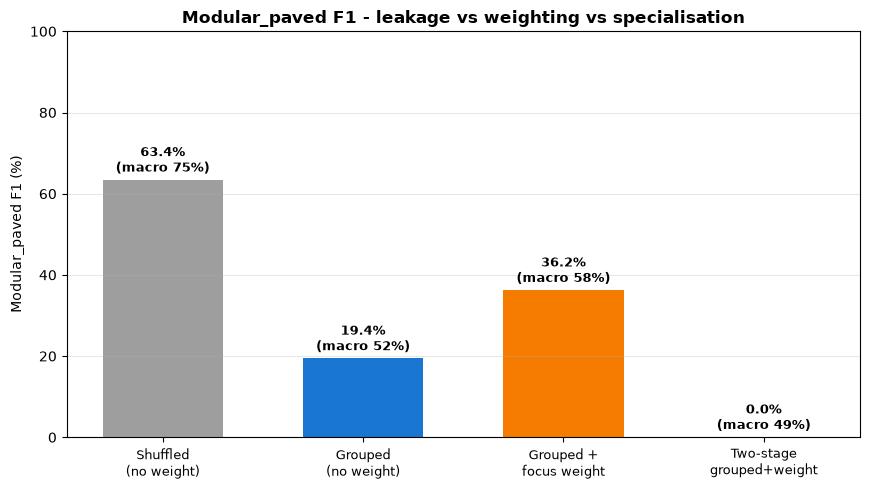

In [8]:
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight

HAS_GRASS = 'grass' in classes
NONGRASS  = [c for c in classes if c != 'grass']
POS_C = NONGRASS[0] if NONGRASS else None
OTH_C = NONGRASS[1] if len(NONGRASS) > 1 else POS_C

def _oof(make_pipe, y, splitter, grp, weight_step=None):
    oof = np.empty(len(y), dtype=object)
    for tr, te in splitter.split(X_tr, y, grp):
        fit_kw = {}
        if weight_step is not None:
            fit_kw[f'{weight_step}__sample_weight'] = compute_sample_weight('balanced', y[tr])
        p = make_pipe(); p.fit(X_tr[tr], y[tr], **fit_kw); oof[te] = p.predict(X_tr[te])
    return oof

def _bin_xgb():
    return Pipeline([('sc', StandardScaler()),
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0))])

def two_stage_oof(y_str, splitter, grp):
    """Stage 1: grass vs rest. Stage 2 (on predicted rest): POS_C vs OTH_C."""
    oof = np.empty(len(y_str), dtype=object)
    for tr, te in splitter.split(X_tr, y_str, grp):
        Xtr, Xte, ytr = X_tr[tr], X_tr[te], y_str[tr]
        y1 = (ytr != 'grass').astype(int)
        m1 = _bin_xgb(); m1.fit(Xtr, y1, xgb__sample_weight=compute_sample_weight('balanced', y1))
        ng = ytr != 'grass'; Xtr2, ytr2 = Xtr[ng], ytr[ng]
        y2 = (ytr2 == POS_C).astype(int)
        m2 = None
        if len(np.unique(y2)) == 2:
            m2 = _bin_xgb(); m2.fit(Xtr2, y2, xgb__sample_weight=compute_sample_weight('balanced', y2))
        p1 = m1.predict(Xte); pred = np.where(p1 == 0, 'grass', None)
        idx = np.where(p1 == 1)[0]
        if len(idx):
            if m2 is None:
                for j in idx: pred[j] = OTH_C
            else:
                p2 = m2.predict(Xte[idx])
                for k, j in enumerate(idx): pred[j] = POS_C if p2[k] == 1 else OTH_C
        oof[te] = pred
    return oof

make_x = lambda: Pipeline([('sc', StandardScaler()),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0))])
shuffled = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

experiments = {}
experiments['Shuffled\n(no weight)'] = le.inverse_transform(_oof(make_x, y_tr_enc, shuffled, None).astype(int))
if GROUPED:
    grp_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    experiments['Grouped\n(no weight)'] = le.inverse_transform(_oof(make_x, y_tr_enc, grp_cv, groups).astype(int))
    experiments['Grouped +\nfocus weight'] = le.inverse_transform(_oof(make_x, y_tr_enc, grp_cv, groups, weight_step='xgb').astype(int))
    if HAS_GRASS:
        experiments['Two-stage\ngrouped+weight'] = two_stage_oof(y_tr, grp_cv, groups)
else:
    print('[WARN] Not grouped - only shuffled baseline shown. Re-run Section 2.')

names   = list(experiments)
focus_f = [f1_score(y_tr, p, labels=classes, average=None)[focus_idx]*100 for p in experiments.values()]
macro_f = [f1_score(y_tr, p, labels=classes, average='macro')*100        for p in experiments.values()]
acc_all = [accuracy_score(y_tr, p)*100                                   for p in experiments.values()]
print(f'{"Setup":24s} {FOCUS_CLASS[:8]+" F1":>9s} {"Macro F1":>9s} {"Accuracy":>9s}')
for n, b, m, a in zip(names, focus_f, macro_f, acc_all):
    print(f'{n.replace(chr(10)," "):24s} {b:8.1f}% {m:8.1f}% {a:8.1f}%')

fig_d, ax_d = plt.subplots(figsize=(max(7, 2.2*len(names)), 5))
palette = ['#9E9E9E', '#1976D2', '#F57C00', '#4CAF50'][:len(names)]
bars = ax_d.bar(range(len(names)), focus_f, color=palette, width=0.6)
for bar, b, m in zip(bars, focus_f, macro_f):
    ax_d.text(bar.get_x()+bar.get_width()/2, b+1.0, f'{b:.1f}%\n(macro {m:.0f}%)', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax_d.set_xticks(range(len(names))); ax_d.set_xticklabels(names, fontsize=9)
ax_d.set_ylabel(f'{FOCUS_CLASS.capitalize()} F1 (%)'); ax_d.set_ylim(0, max(100, max(focus_f)+12))
ax_d.set_title(f'{FOCUS_CLASS.capitalize()} F1 - leakage vs weighting vs specialisation', fontweight='bold', fontsize=12)
ax_d.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, f'{FOCUS_CLASS}_diagnosis.png'), bbox_inches='tight', dpi=150); plt.show()


## 5. Dashboard — Scores, Confusion Matrices, Feature Importance

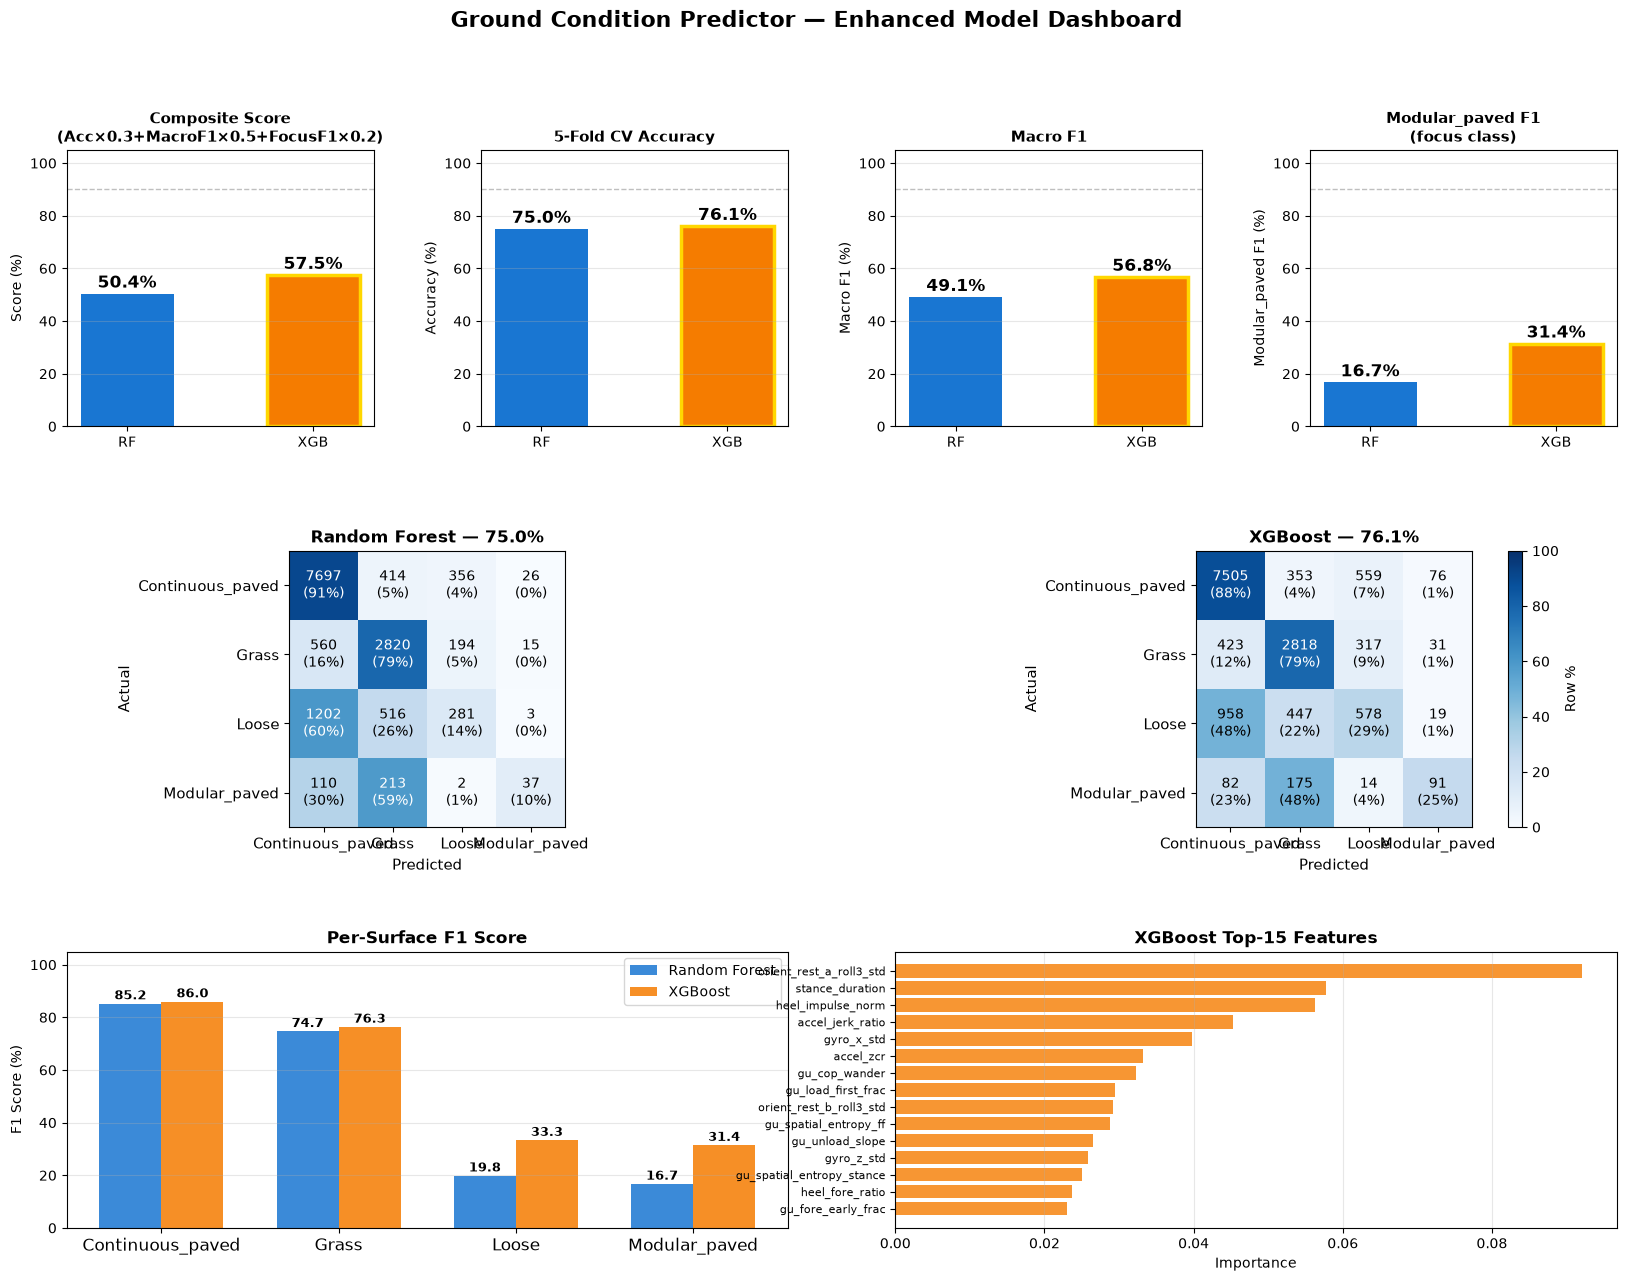


── XGBoost Classification Report ──
                  precision    recall  f1-score   support

continuous_paved      0.837     0.884     0.860      8493
           grass      0.743     0.785     0.763      3589
           loose      0.394     0.289     0.333      2002
   modular_paved      0.419     0.251     0.314       362

        accuracy                          0.761     14446
       macro avg      0.598     0.552     0.568     14446
    weighted avg      0.742     0.761     0.749     14446



In [9]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Ground Condition Predictor — Enhanced Model Dashboard',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

def score_bar(ax, rf_val, xgb_val, title, ylabel):
    vals  = [rf_val*100, xgb_val*100]
    bars  = ax.bar(['RF','XGB'], vals, color=['#1976D2','#F57C00'], width=0.5)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 105); ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10); ax.grid(axis='y', alpha=0.3)
    ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.5)
    winner_idx = 1 if xgb_val >= rf_val else 0
    bars[winner_idx].set_edgecolor('gold'); bars[winner_idx].set_linewidth(2.5)

# Row 0: four summary bars
score_bar(fig.add_subplot(gs[0,0]), cs_rf,             cs_xgb,             'Composite Score\n(Acc×0.3+MacroF1×0.5+FocusF1×0.2)', 'Score (%)')
score_bar(fig.add_subplot(gs[0,1]), acc_rf,            acc_xgb,            '5-Fold CV Accuracy', 'Accuracy (%)')
score_bar(fig.add_subplot(gs[0,2]), mf1_rf,            mf1_xgb,            'Macro F1', 'Macro F1 (%)')
score_bar(fig.add_subplot(gs[0,3]), f1_rf[focus_idx],  f1_xgb[focus_idx],  f'{FOCUS_CLASS.capitalize()} F1\n(focus class)', f'{FOCUS_CLASS.capitalize()} F1 (%)')

# Row 1: confusion matrices (row-normalised)
for col_pos, y_cv, title, acc in [
    (slice(0,2), y_cv_rf,         f'Random Forest — {acc_rf*100:.1f}%', acc_rf),
    (slice(2,4), y_cv_xgb_labels, f'XGBoost — {acc_xgb*100:.1f}%',     acc_xgb)
]:
    ax = fig.add_subplot(gs[1, col_pos])
    cm = confusion_matrix(y_tr, y_cv, labels=classes)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels([c.capitalize() for c in classes], fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]}\n({cm_n[i,j]:.0f}%)', ha='center', va='center',
                    color='white' if cm_n[i,j]>55 else 'black', fontsize=10)
plt.colorbar(im, ax=fig.axes[-1], label='Row %')

# Row 2: per-surface F1 grouped bar + XGB feature importance
ax_f1 = fig.add_subplot(gs[2, :2])
x = np.arange(len(classes)); width=0.35
b_rf  = ax_f1.bar(x-width/2, f1_rf*100,  width, label='Random Forest', color='#1976D2', alpha=0.85)
b_xgb = ax_f1.bar(x+width/2, f1_xgb*100, width, label='XGBoost',       color='#F57C00', alpha=0.85)
for bars_ in [b_rf, b_xgb]:
    for bar in bars_:
        ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_f1.set_xticks(x); ax_f1.set_xticklabels([c.capitalize() for c in classes], fontsize=12)
ax_f1.set_ylabel('F1 Score (%)'); ax_f1.set_ylim(0, 105)
ax_f1.set_title('Per-Surface F1 Score', fontweight='bold', fontsize=12)
ax_f1.legend(fontsize=10); ax_f1.grid(axis='y', alpha=0.3)

ax_fi = fig.add_subplot(gs[2, 2:])
xgb_imp = xgb_pipe.named_steps['xgb'].feature_importances_
top_n   = 15; top_idx = np.argsort(xgb_imp)[::-1][:top_n]
ax_fi.barh(range(top_n), xgb_imp[top_idx][::-1], color='#F57C00', alpha=0.8)
ax_fi.set_yticks(range(top_n))
ax_fi.set_yticklabels([FEATURE_COLS[i] for i in top_idx[::-1]], fontsize=8)
ax_fi.set_xlabel('Importance')
ax_fi.set_title('XGBoost Top-15 Features', fontweight='bold', fontsize=12)
ax_fi.grid(axis='x', alpha=0.3)

plt.savefig(os.path.join(CHARTS_DIR, 'dashboard.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\n── XGBoost Classification Report ──')
print(classification_report(y_tr, y_cv_xgb_labels, digits=3))

## 6. Feature Distributions by Surface

The eight features that best **separate the four surface classes**, chosen automatically by ANOVA F-statistic over the model's feature set (higher F = larger between-class vs. within-class variance). Each panel overlays the per-surface distributions; where the coloured humps sit apart, that feature discriminates the classes.

Most class-differentiable features (ANOVA F):
orient_rest_a_roll3_std      1765.0
accel_jerk_ratio              846.1
orient_rest_b_roll3_std       795.8
gyro_x_std                    611.5
stance_duration               362.0
gyro_z_std                    271.9
accel_spec_centroid           271.6
gyro_x_strike                 258.8
accel_zcr                     249.5
accel_hf_frac                 247.3
accel_spec_entropy            233.6
gu_spatial_entropy_stance     226.1


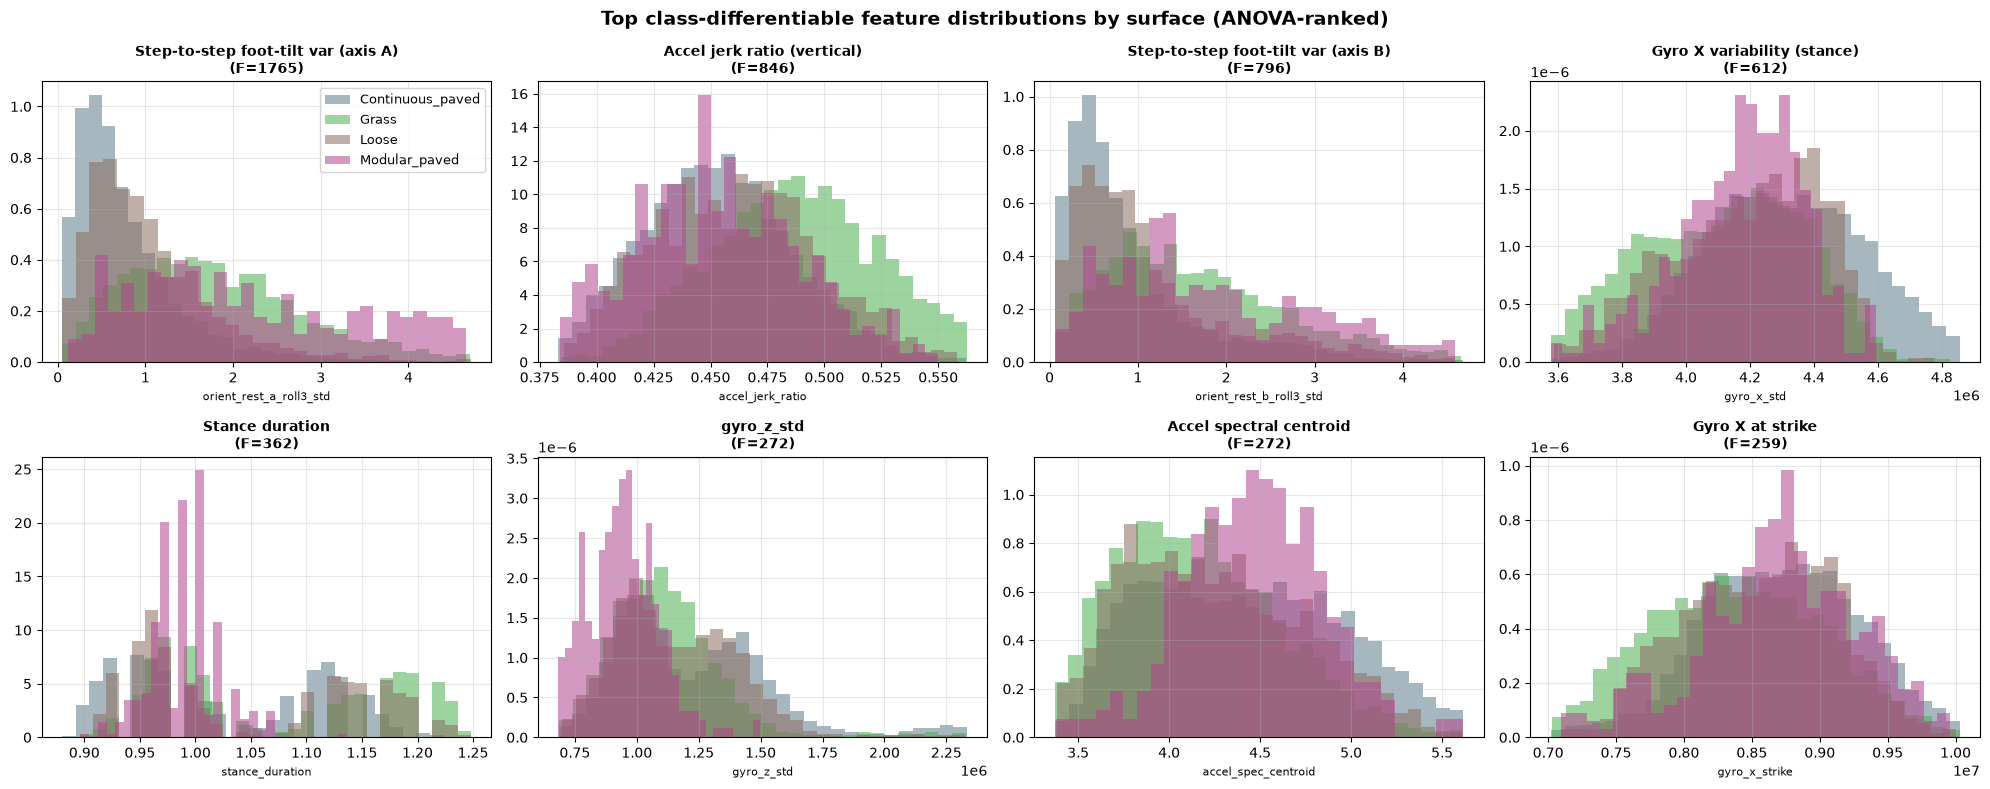

In [10]:
# ===== Section 6: distributions of the MOST CLASS-DIFFERENTIABLE features =====
# Instead of a hand-picked list, rank the model's own features (FEATURE_COLS) by how
# well they separate the surfaces, using the ANOVA F-statistic (between-class variance
# / within-class variance). Then plot the top 8. This always matches the features the
# model actually uses and highlights the ones that carry the class signal.
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler as _SS

_Xz = _SS().fit_transform(train_df[FEATURE_COLS].fillna(0).values)
_F, _p = f_classif(_Xz, train_df['surface'].values)
fsep = pd.Series(_F, index=FEATURE_COLS).sort_values(ascending=False)
key_feats = fsep.head(8).index.tolist()
print('Most class-differentiable features (ANOVA F):')
print(fsep.head(12).round(1).to_string())

_nice = {'orient_rest_a_roll3_std':'Step-to-step foot-tilt var (axis A)',
         'orient_rest_b_roll3_std':'Step-to-step foot-tilt var (axis B)',
         'accel_jerk_ratio':'Accel jerk ratio (vertical)','gyro_x_std':'Gyro X variability (stance)',
         'stance_duration':'Stance duration','gyro_x_strike':'Gyro X at strike',
         'accel_hf_frac':'Accel high-freq fraction','accel_spec_centroid':'Accel spectral centroid',
         'gu_spatial_entropy_stance':'Pressure-map entropy (stance)','accel_spec_entropy':'Accel spectral entropy',
         'gyro_hf_frac':'Gyro high-freq fraction','heel_impulse_norm':'Heel impulse (norm)',
         'gu_unload_slope':'Unloading slope (norm)','heel_fore_ratio':'Heel/forefoot ratio'}

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 8))
fig2.suptitle('Top class-differentiable feature distributions by surface (ANOVA-ranked)',
              fontsize=14, fontweight='bold')
for ax, feat in zip(axes2.flat, key_feats):
    vals_all = train_df[feat].replace([np.inf,-np.inf], np.nan).dropna()
    lo, hi = vals_all.quantile(0.01), vals_all.quantile(0.99)          # clip outliers for readability
    for surf in list(classes):
        v = train_df[train_df['surface']==surf][feat]
        v = v[(v>=lo)&(v<=hi)].dropna()
        ax.hist(v, bins=30, alpha=0.55, color=SURFACE_COLORS.get(surf,'#9E9E9E'),
                label=str(surf).capitalize(), density=True)
    ax.set_title(f"{_nice.get(feat, feat)}\n(F={fsep[feat]:.0f})", fontweight='bold', fontsize=10)
    ax.set_xlabel(feat, fontsize=8); ax.grid(alpha=0.3)
    if feat == key_feats[0]: ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'feature_distributions.png'), bbox_inches='tight', dpi=150)
plt.show()

## 7. Predict on New CSV + Sequence Smoothing

In [11]:
# Exactly ONE REC_*.csv should sit in the Raw/New Data folder; use it.
_new_files = sorted(glob.glob(os.path.join(RAW_NEW_DIR, REC_GLOB)))
if len(_new_files) != 1:
    raise FileNotFoundError(
        f'Expected exactly 1 {REC_GLOB} in {RAW_NEW_DIR}, found {len(_new_files)}: '
        f'{[os.path.basename(f) for f in _new_files]}'
    )
NEW_CSV_PATH = _new_files[0]
NEW_CSV_NAME = os.path.basename(NEW_CSV_PATH)

print(f'Loading: {NEW_CSV_NAME}  |  Model: {best_name}')
new_raw = pd.read_csv(NEW_CSV_PATH, low_memory=False)
ss_new  = compute_session_stats(new_raw)

pred_frames = []
for sole_id, foot in [(1,'right'), (2,'left')]:
    sub = new_raw[new_raw['sole_id'] == sole_id].copy()
    labelled = label_surface_segments(sub)
    df_proc  = preprocess(labelled if labelled is not None else sub)
    feats = extract_step_features(df_proc, foot_label=foot, session_stats=ss_new)
    if len(feats):
        pred_frames.append(feats)
        print(f'  {foot}: {len(feats)} steps')

pred_df = pd.concat(pred_frames, ignore_index=True)
X_pred  = pred_df[FEATURE_COLS].fillna(0).values

if use_encoded:
    pred_df['predicted_surface'] = le.inverse_transform(best_pipe.predict(X_pred))
    proba = best_pipe.predict_proba(X_pred)
else:
    pred_df['predicted_surface'] = best_pipe.predict(X_pred)
    proba = best_pipe.predict_proba(X_pred)

for i, c in enumerate(classes): pred_df[f'prob_{c}'] = proba[:, i]
pred_df['max_confidence'] = proba.max(axis=1)

# Sequence smoothing
pred_df['smoothed_surface'] = pred_df.groupby('foot')['predicted_surface'].transform(
    lambda s: rolling_majority(s, window=5)
)

print(f'\nRaw predictions:')
print(pred_df.groupby(['foot','predicted_surface']).size().unstack(fill_value=0))
print(f'\nSmoothed predictions:')
print(pred_df.groupby(['foot','smoothed_surface']).size().unstack(fill_value=0))
print(f'\nMean confidence: {pred_df["max_confidence"].mean()*100:.1f}%')

# -- Predicted STEP COUNTS per surface (this recording) --
print(f'\n-- Predicted step counts per surface ({NEW_CSV_NAME}) --')
_raw = pred_df['predicted_surface'].value_counts().reindex(classes, fill_value=0)
_sm  = pred_df['smoothed_surface'].value_counts().reindex(classes, fill_value=0)
_summary = pd.DataFrame({'raw_steps': _raw, 'smoothed_steps': _sm})
_summary['pct_smoothed'] = (_summary['smoothed_steps'] / max(_summary['smoothed_steps'].sum(),1) * 100).round(1)
print(_summary.to_string())
print(f'TOTAL steps: {len(pred_df)}   |   dominant surface (smoothed): {_sm.idxmax()} ({_sm.max()} steps)')

FileNotFoundError: Expected exactly 1 REC_*.csv in ..\Raw_New Data, found 0: []

## 7b. File the recording into its owner's folder

In [ ]:
# Move the just-predicted recording out of Raw/New Data and into its owner's
# user folder, so the next Section-2 run folds it into the material training set.

# ── Fill in which user this recording belongs to ──────────────────────
ASSIGN_TO_USER = ''   # ← e.g. 'Amy', 'Catherine', 'Kristian'

if not ASSIGN_TO_USER:
    raise ValueError('Set ASSIGN_TO_USER to the user this recording belongs to before running.')

dest_dir  = os.path.join(USERS_DIR, ASSIGN_TO_USER)
os.makedirs(dest_dir, exist_ok=True)
dest_path = os.path.join(dest_dir, NEW_CSV_NAME)

if os.path.exists(dest_path):
    raise FileExistsError(f'{NEW_CSV_NAME} already exists in {dest_dir}; not overwriting.')

shutil.move(NEW_CSV_PATH, dest_path)
print(f'Moved {NEW_CSV_NAME}  →  {dest_path}')
print('Re-run Section 2 to fold this recording into the material training files.')

## 8. Prediction Visualisation (Raw vs Smoothed)

In [ ]:
surf_to_int = {s: i for i, s in enumerate(classes)}
int_to_surf = {i: s for s, i in surf_to_int.items()}

fig3, axes3 = plt.subplots(2, 2, figsize=(18, 8))
fig3.suptitle(
    f'Prediction vs Smoothed — {NEW_CSV_NAME}\n'
    f'{best_name} | Mean confidence: {pred_df["max_confidence"].mean()*100:.1f}%',
    fontsize=13, fontweight='bold'
)
for ri, foot in enumerate(['right', 'left']):
    sub = pred_df[pred_df['foot'] == foot].reset_index(drop=True)
    x_ax = sub['contact_time_sec'].values
    for ci, (col, title) in enumerate([
        ('predicted_surface', f'{foot.capitalize()} — Raw'),
        ('smoothed_surface',  f'{foot.capitalize()} — Smoothed (window=5)')
    ]):
        ax = axes3[ri, ci]
        vals = sub[col].map(surf_to_int).values
        colors_plot = [SURFACE_COLORS.get(int_to_surf.get(v,'unknown'),'#9E9E9E') for v in vals]
        ax.scatter(x_ax, vals, c=colors_plot, s=25, alpha=0.85, zorder=3)
        if 'surface' in sub.columns:
            gt = sub['surface'].map(surf_to_int)
            ax.step(x_ax, gt.values, where='post', color='black', lw=1.5,
                    alpha=0.5, label='Ground truth')
            ax.legend(fontsize=9)
        ax.set_yticks(list(surf_to_int.values()))
        ax.set_yticklabels([c.capitalize() for c in classes], fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Contact time (s)'); ax.grid(alpha=0.3)

patches = [plt.Rectangle((0,0),1,1,color=SURFACE_COLORS[s]) for s in classes]
fig3.legend(patches, [c.capitalize() for c in classes], loc='lower center',
            ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sequence_smoothing.png'), bbox_inches='tight', dpi=150)
plt.show()

## 9. Export Predictions

In [ ]:
out_path = os.path.join(PRED_DIR, NEW_CSV_NAME.replace('.csv', '_predictions_v2.csv'))
pred_df[['foot','step_id','contact_time_sec','stance_duration',
         'impact_mag','loading_rate','predicted_surface','smoothed_surface','max_confidence']
       + [f'prob_{c}' for c in classes]
       ].to_csv(out_path, index=False)
print(f'Saved → {out_path}')

## 10. Sequence model — 1D temporal CNN on raw step windows

Instead of hand-engineered per-step summaries, this feeds the model the **raw
multichannel waveform of each step** (9 channels × 64 time-steps) and lets a 1D
CNN learn its own shape/texture detectors — the idea being it can pick up the
fine surface-texture patterns directly.

**Requires PyTorch** (`pip install torch`) and that Sections 1–4 have already run
(it reuses `le`, `classes`, `focus_idx`, `CLASS_WEIGHT_STRENGTH`, and the XGBoost
grouped scores for comparison).

**Read this before trusting the result.** Each step's channels are z-scored
individually, so the CNN sees shape, not magnitude — the same session-invariance
principle as the texture features. Evaluation uses the *same* grouped CV as the
trees, so compare against the **grouped** XGBoost focus-class F1, never the shuffled one.
With a few thousand steps and the focus class in a limited number of recordings, a CNN can
easily overfit and lose to the trees; if grouped focus-class F1 doesn't beat XGBoost,
that's the honest answer, not a tuning failure.

In [12]:
# ── Requires PyTorch:  pip install torch ──────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold

T_LEN = 64
SEQ_CHANNELS = ['heel_sum','fore_sum','total_p','accel_x','accel_y','accel_z',
                'gyro_x','gyro_y','gyro_z']

def _resample_zscore(win, T=T_LEN):
    """[L, C] raw window -> [T, C], each channel z-scored (magnitude removed)."""
    L, C = win.shape
    if L < 2: return None
    xi = np.linspace(0, L-1, T); out = np.empty((T, C), float)
    for c in range(C):
        r = np.interp(xi, np.arange(L), win[:, c]); sd = r.std()
        out[:, c] = (r - r.mean()) / (sd if sd > 1e-8 else 1.0)
    return out

def _channel_matrix(df):
    num = lambda cols: df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
    g   = lambda c: pd.to_numeric(df[c], errors='coerce').fillna(0).to_numpy(float)
    return np.column_stack([
        num(HEEL_SENSORS).sum(1), num(FOREFOOT_SENSORS).sum(1), num(ALL_SENSORS).sum(1),
        g('accel_x'), g('accel_y'), g('accel_z'), g('gyro_x'), g('gyro_y'), g('gyro_z')])

def step_windows_from_df(df, stats=None):
    """Raw step windows + surface label, gated exactly as Section 2 gates the
    per-step feature table: a step that touches a transition/wait region, spans a
    surface change, or is only partly labelled is dropped, not majority-voted."""
    peaks = find_step_windows(df)
    if len(peaks) < 2: return [], []
    M = _channel_matrix(df)
    has_labels = ('surface' in df.columns) and bool(df['surface'].notna().any())
    surf_col = df['surface'].values if has_labels else None
    wins, surfs = [], []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 < MIN_DP: continue
        s = None
        if has_labels:
            s, drop = step_surface_label(surf_col[p1:p2], stats=stats)
            if drop: continue
        w = _resample_zscore(M[p1:p2])
        if w is None: continue
        wins.append(w); surfs.append(s)
    return wins, surfs

# Build the raw-window dataset from every user recording. Same recordings, same
# quality gate and same step gate as Section 2, so the two datasets line up.
Xseq_l, yseq_l, grp_l = [], [], []
_SEQ_STATS = {'seen': 0, 'transition': 0, 'partial': 0, 'kept': 0, 'excluded': 0}
recs = []
if os.path.isdir(USERS_DIR):
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if os.path.isdir(udir):
            recs += sorted(glob.glob(os.path.join(udir, REC_GLOB)))
for path in recs:
    raw = pd.read_csv(path, low_memory=False)
    if QUALITY_CHECK and QUALITY_SKIP_BAD and not check_recording_quality(raw, path)[0]:
        continue
    for sole_id, foot in [(1,'right'), (2,'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        lab = label_surface_segments(sub)
        if lab is None or len(lab) == 0: continue
        lab = preprocess(lab)
        wins, surfs = step_windows_from_df(lab, stats=_SEQ_STATS)
        for w, s in zip(wins, surfs):
            if s in list(classes):
                Xseq_l.append(w); yseq_l.append(s); grp_l.append(os.path.basename(path))

Xseq    = np.stack(Xseq_l).astype('float32')     # [N, T, C]
yseq    = le.transform(np.array(yseq_l))
grp_seq = np.array(grp_l)
print('Sequence dataset:', Xseq.shape, '(steps, time, channels)')
print('Class counts:', dict(zip(*np.unique(le.inverse_transform(yseq), return_counts=True))))
_gc = {c: int(np.unique(grp_seq[le.inverse_transform(yseq) == c]).size) for c in classes}
print('Recordings per class:', _gc)
SEQ_SPLITS = int(min(5, min(_gc.values())))
print('Grouped folds:', SEQ_SPLITS)
print(f"Excluded-region steps dropped: {_SEQ_STATS['excluded']}  |  "
      f"transition-spanning: {_SEQ_STATS['transition']}  |  "
      f"partial/edge: {_SEQ_STATS['partial']}")

# ── reconcile against the per-step feature table from Section 2 ──────
_seq_counts  = pd.Series(le.inverse_transform(yseq)).value_counts()
_tree_counts = train_df['surface'].value_counts()
_cmp = pd.DataFrame({'tree': _tree_counts, 'sequence': _seq_counts}).fillna(0).astype(int)
_cmp['diff'] = _cmp['sequence'] - _cmp['tree']
_cmp.loc['TOTAL'] = _cmp.sum()
print('\nSteps per class - tree path vs sequence path:')
print(_cmp.to_string())
_seq_groups  = {c: int(np.unique(grp_seq[le.inverse_transform(yseq) == c]).size) for c in classes}
_tree_groups = train_df.groupby('surface')['source_recording'].nunique().to_dict()
print(f'Recordings per class - tree {_tree_groups}  sequence {_seq_groups}')
if int(_cmp.loc['TOTAL', 'diff']) != 0 or _seq_groups != _tree_groups:
    print('[WARN] the two paths are not scoring the same steps - the XGBoost vs CNN '
          'comparison below is not like-for-like until this reads 0.')
else:
    print('OK - both paths keep the same steps, so the model comparison is like-for-like.')

Sequence dataset: (14446, 64, 9) (steps, time, channels)
Class counts: {'continuous_paved': np.int64(8493), 'grass': np.int64(3589), 'loose': np.int64(2002), 'modular_paved': np.int64(362)}
Recordings per class: {'continuous_paved': 39, 'grass': 26, 'loose': 16, 'modular_paved': 4}
Grouped folds: 4
Excluded-region steps dropped: 1111  |  transition-spanning: 0  |  partial/edge: 0

Steps per class - tree path vs sequence path:
                   tree  sequence  diff
continuous_paved   8493      8493     0
grass              3589      3589     0
loose              2002      2002     0
modular_paved       362       362     0
TOTAL             14446     14446     0
Recordings per class - tree {'continuous_paved': 39, 'grass': 26, 'loose': 16, 'modular_paved': 4}  sequence {'continuous_paved': 39, 'grass': 26, 'loose': 16, 'modular_paved': 4}
OK - both paths keep the same steps, so the model comparison is like-for-like.


### Train & evaluate under grouped CV

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

class Conv1dNet(nn.Module):
    def __init__(self, C, n_classes):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv1d(C, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten())
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(64, 64), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(64, n_classes))
    def forward(self, x):                 # x: [B, T, C] -> [B, C, T]
        return self.head(self.body(x.transpose(1, 2)))

def train_fold(Xtr, ytr, Xva, yva, n_classes, cls_w,
               max_epochs=80, patience=12, bs=64, lr=1e-3):
    model = Conv1dNet(Xtr.shape[2], n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss(weight=torch.tensor(cls_w, dtype=torch.float32, device=device))
    ds    = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
    dl    = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=len(Xtr) >= bs)  # drop_last: avoid size-1 BatchNorm batch
    Xva_t = torch.tensor(Xva).to(device)
    best_f1, best_state, wait = -1.0, None, 0
    for _ in range(max_epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); lossf(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(Xva_t).argmax(1).cpu().numpy()
        vf1 = f1_score(yva, vp, average='macro')
        if vf1 > best_f1:
            best_f1, wait = vf1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state: model.load_state_dict(best_state)
    return model

# Softened class weights — reuses the Section-4 CLASS_WEIGHT_STRENGTH dial
_cnt  = np.bincount(yseq, minlength=len(classes)).astype(float)
cls_w = (len(yseq) / (len(classes) * _cnt)) ** CLASS_WEIGHT_STRENGTH
cls_w = cls_w / cls_w.mean()

sgkf_seq = StratifiedGroupKFold(n_splits=SEQ_SPLITS, shuffle=True, random_state=42)
oof = np.full(len(yseq), -1, int)
for fold, (tr, te) in enumerate(sgkf_seq.split(Xseq, yseq, grp_seq), 1):
    # grouped internal validation split (whole recordings) for early stopping
    gtr = np.unique(grp_seq[tr]); rs = np.random.RandomState(fold); rs.shuffle(gtr)
    val_g = set(gtr[:max(1, int(0.2 * len(gtr)))])
    vm = np.array([g in val_g for g in grp_seq[tr]])
    tr_i, va_i = tr[~vm], tr[vm]
    m = train_fold(Xseq[tr_i], yseq[tr_i], Xseq[va_i], yseq[va_i], len(classes), cls_w)
    m.eval()
    with torch.no_grad():
        oof[te] = m(torch.tensor(Xseq[te]).to(device)).argmax(1).cpu().numpy()
    print(f'  fold {fold}/{SEQ_SPLITS} done')

seq_true = le.inverse_transform(yseq)
seq_lbl  = le.inverse_transform(oof)
acc_seq  = accuracy_score(seq_true, seq_lbl)
f1_seq   = f1_score(seq_true, seq_lbl, labels=classes, average=None)
mf1_seq  = float(np.mean(f1_seq))
print(f'\n1D-CNN (grouped) — Acc {acc_seq*100:.1f}%  MacroF1 {mf1_seq*100:.1f}%  {FOCUS_CLASS} F1 {f1_seq[focus_idx]*100:.1f}%')

  fold 1/4 done
  fold 2/4 done
  fold 3/4 done
  fold 4/4 done

1D-CNN (grouped) — Acc 83.5%  MacroF1 66.0%  modular_paved F1 29.6%


### Compare to the tree baseline (grouped CV)

model                      Modular_paved F1  Macro F1  Accuracy
XGBoost (grouped+weight)       31.4%     56.8%     76.1%
1D-CNN (grouped+weight)        29.6%     66.0%     83.5%


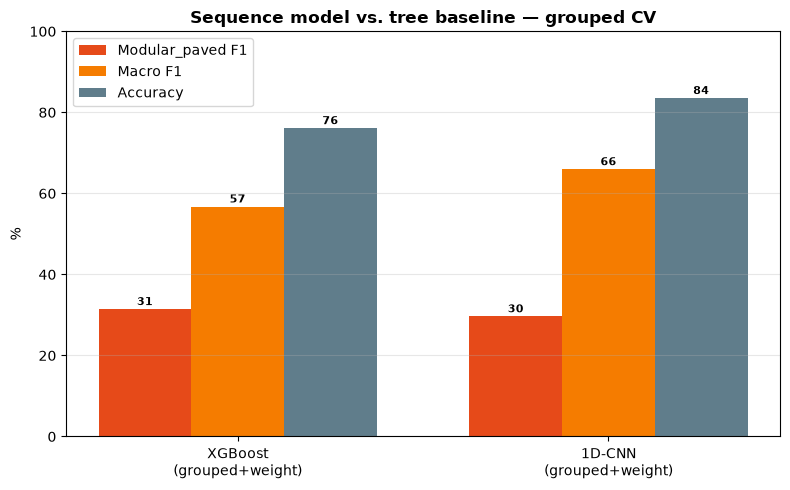


CNN confusion matrix (rows = actual):
                  Continuous_paved  Grass  Loose  Modular_paved
Continuous_paved              7913    121    179            280
Grass                          255   3013    194            127
Loose                          666    273    993             70
Modular_paved                   63    136     17            146


In [14]:
labels = ['XGBoost\n(grouped+weight)', '1D-CNN\n(grouped+weight)']
focus  = [f1_xgb[focus_idx]*100, f1_seq[focus_idx]*100]
macro  = [mf1_xgb*100,           mf1_seq*100]
acc    = [acc_xgb*100,           acc_seq*100]

print(f'{"model":26s} {FOCUS_CLASS.capitalize()+" F1":>9s} {"Macro F1":>9s} {"Accuracy":>9s}')
for n, b, m, a in zip(labels, focus, macro, acc):
    print(f'{n.replace(chr(10)," "):26s} {b:8.1f}% {m:8.1f}% {a:8.1f}%')

fig_s, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2); w = 0.25
ax.bar(x-w, focus, w, label=f'{FOCUS_CLASS.capitalize()} F1', color='#E64A19')
ax.bar(x,   macro, w, label='Macro F1', color='#F57C00')
ax.bar(x+w, acc,   w, label='Accuracy', color='#607D8B')
for xi, vals in zip(x, zip(focus, macro, acc)):
    for dx, v in zip([-w, 0, w], vals):
        ax.text(xi+dx, v+1, f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 100)
ax.set_ylabel('%'); ax.grid(axis='y', alpha=0.3); ax.legend()
ax.set_title('Sequence model vs. tree baseline — grouped CV', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sequence_model_cnn.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\nCNN confusion matrix (rows = actual):')
print(pd.DataFrame(confusion_matrix(seq_true, seq_lbl, labels=classes),
                   index=[c.capitalize() for c in classes],
                   columns=[c.capitalize() for c in classes]).to_string())

### CNN confusion matrix (grouped CV)

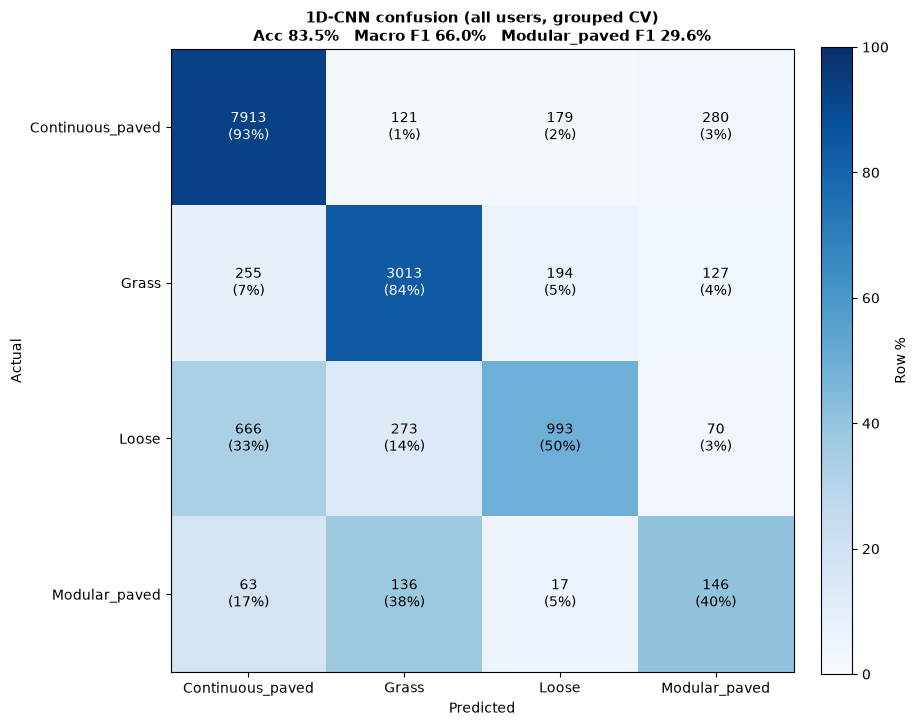

CNN per-class (grouped CV):
  continuous_paved  recall  93.2%   precision  88.9%   (n=8493)
  grass   recall  84.0%   precision  85.0%   (n=3589)
  loose   recall  49.6%   precision  71.8%   (n=2002)
  modular_paved  recall  40.3%   precision  23.4%   (n=362)


In [15]:
# 1D-CNN confusion matrix — heatmap (rows = actual, annotated with count + row %)
from sklearn.metrics import confusion_matrix

_cm  = confusion_matrix(seq_true, seq_lbl, labels=classes)
_row = _cm.sum(axis=1, keepdims=True)
_pct = np.divide(_cm, _row, where=_row != 0, out=np.zeros_like(_cm, dtype=float)) * 100

fig_cm, axcm = plt.subplots(figsize=(1.7*len(classes)+2, 1.5*len(classes)+1.5))
im = axcm.imshow(_pct, cmap='Blues', vmin=0, vmax=100)
axcm.set_xticks(range(len(classes))); axcm.set_xticklabels([c.capitalize() for c in classes])
axcm.set_yticks(range(len(classes))); axcm.set_yticklabels([c.capitalize() for c in classes])
axcm.set_xlabel('Predicted'); axcm.set_ylabel('Actual')
axcm.set_title(f'1D-CNN confusion (all users, grouped CV)\n'
               f'Acc {acc_seq*100:.1f}%   Macro F1 {mf1_seq*100:.1f}%   '
               f'{FOCUS_CLASS.capitalize()} F1 {f1_seq[focus_idx]*100:.1f}%',
               fontweight='bold', fontsize=11)
for i in range(len(classes)):
    for j in range(len(classes)):
        axcm.text(j, i, f'{_cm[i, j]}\n({_pct[i, j]:.0f}%)', ha='center', va='center',
                  color='white' if _pct[i, j] > 55 else 'black', fontsize=10)
cbar = fig_cm.colorbar(im, ax=axcm, fraction=0.046, pad=0.04); cbar.set_label('Row %')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'cnn_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()

print('CNN per-class (grouped CV):')
for i, cl in enumerate(classes):
    rec = _cm[i, i] / _row[i, 0] * 100 if _row[i, 0] else float('nan')
    col = _cm[:, i].sum(); prec = _cm[i, i] / col * 100 if col else float('nan')
    print(f'  {cl:6s}  recall {rec:5.1f}%   precision {prec:5.1f}%   (n={int(_row[i,0])})')

## 11. Appendix — feature importance, pruning, and hardness / evenness scales

**Which features matter (and which to drop).** In-sample RandomForest importance tells you what the model *uses*, but that includes person-confounds. The honest test is **cross-user (leave-one-user-out) permutation importance**: shuffle each feature and measure how much it hurts prediction on a *held-out person*. Features with importance ≤ 0 don't help a new user and are prune candidates — the cell then **re-tests user-grouped macro F1 with them removed** so you can see if pruning actually helps. Repeat: prune the clearly-negative ones, re-run, keep what improves or holds.

**Hardness / evenness scales.** Two interpretable per-step axes: hardness = out-of-fold P(firm) from compliance features; evenness = inverted irregularity composite. The plots show how the surfaces populate each axis.

TOP cross-user features:
                         crossuser_perm(x1000)  insample_rf
orient_rest_a_roll3_std                   45.8       0.0800
accel_jerk_ratio                          26.0       0.0474
accel_mag_strike                           8.7       0.0186
accel_spec_centroid                        8.3       0.0153
orient_range_a                             7.9       0.0151
gyro_x_std                                 7.9       0.0452
gyro_z_std                                 6.2       0.0298
gu_push_peak                               3.7       0.0139
gyro_x_strike                              3.5       0.0158
gyro_hf_frac                               3.2       0.0102
accel_hf_frac                              3.2       0.0205
gyro_mag_strike                            2.9       0.0114

BOTTOM (hurt/useless for a new user):
                    crossuser_perm(x1000)  insample_rf
gu_unload_slope                      -0.7       0.0330
heel_kurt                            -1.0     

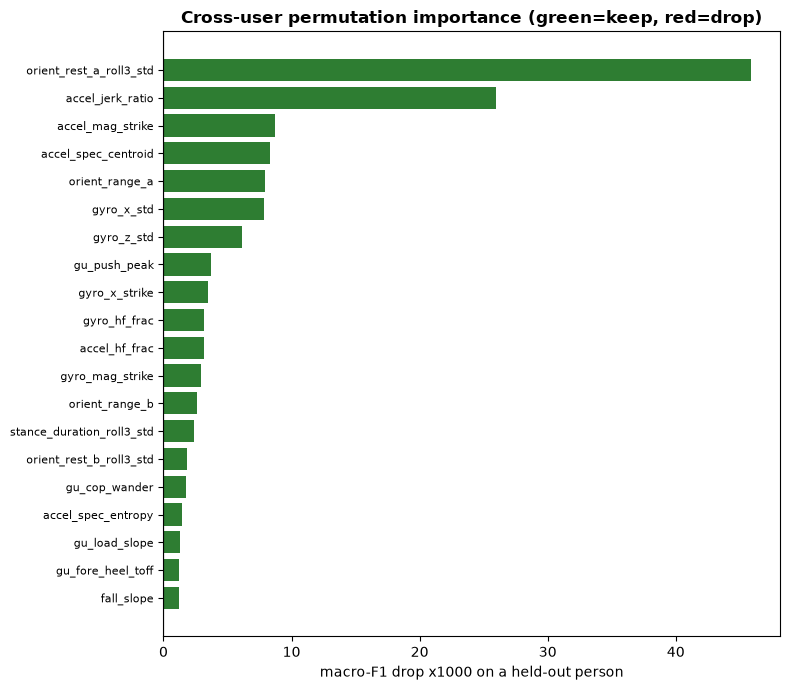

In [16]:
# ===== (A/B/C) feature importance + honest cross-user pruning =====
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier as _HGB
from sklearn.model_selection import StratifiedGroupKFold as _SGK
from sklearn.metrics import f1_score as _f1
from sklearn.utils.class_weight import compute_sample_weight as _csw

FEATS = list(FEATURE_COLS)                       # from Section 3 (confounds already excluded)
Xa = full_df[FEATS].fillna(0).values; ya = full_df['surface'].values
usr = full_df['source_user'].values; users = sorted(set(usr)); classes_a = sorted(set(ya))

# (A) in-sample RF importance
_rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight='balanced',
                             random_state=42, n_jobs=-1).fit(Xa, ya)
insamp = pd.Series(_rf.feature_importances_, index=FEATS)

# (B) cross-user (leave-one-user-out) permutation importance
_rng = np.random.default_rng(0); _drops = {f: [] for f in FEATS}
for u in users:
    tr = usr != u; te = usr == u
    _m = _HGB(max_depth=5, learning_rate=0.05, max_iter=250, random_state=0)
    _m.fit(Xa[tr], ya[tr], sample_weight=_csw('balanced', ya[tr]))
    base = _f1(ya[te], _m.predict(Xa[te]), labels=classes_a, average='macro')
    Xte = Xa[te].copy()
    for j, f in enumerate(FEATS):
        col = Xte[:, j].copy(); dd = []
        for _ in range(2):
            Xte[:, j] = _rng.permutation(col)
            dd.append(base - _f1(ya[te], _m.predict(Xte), labels=classes_a, average='macro'))
        Xte[:, j] = col; _drops[f].append(np.mean(dd))
perm = (pd.Series({f: np.mean(v) for f, v in _drops.items()}) * 1000).sort_values(ascending=False)
cmp = pd.DataFrame({'crossuser_perm(x1000)': perm.round(1),
                    'insample_rf': insamp.reindex(perm.index).round(4)})
print('TOP cross-user features:'); print(cmp.head(12).to_string())
print('\nBOTTOM (hurt/useless for a new user):'); print(cmp.tail(8).to_string())
PRUNE = perm[perm <= 0].index.tolist()
print(f'\nPrune candidates (<=0 cross-user): {len(PRUNE)}')
print(PRUNE)

# (C) prune-and-retest under USER-grouped CV
def _ug_macro(cols):
    Xc = full_df[cols].fillna(0).values; oof = np.empty(len(ya), object)
    for tr, te in _SGK(3, shuffle=True, random_state=42).split(Xc, ya, usr):
        m = _HGB(max_depth=5, learning_rate=0.05, max_iter=300, random_state=42)
        m.fit(Xc[tr], ya[tr], sample_weight=_csw('balanced', ya[tr])); oof[te] = m.predict(Xc[te])
    return _f1(ya, oof, average='macro') * 100
_kept = [c for c in FEATS if c not in PRUNE]
print(f'\nUser-grouped macro F1:  all {len(FEATS)} = {_ug_macro(FEATS):.1f}%   '
      f'|   pruned to {len(_kept)} = {_ug_macro(_kept):.1f}%')
print('If pruned >= all, adopt PRUNED_FEATURES = _kept for the final model.')

fig, ax = plt.subplots(figsize=(8, 7)); top = perm.head(20)[::-1]
ax.barh(range(len(top)), top.values, color=['#C62828' if v <= 0 else '#2E7D32' for v in top.values])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8); ax.axvline(0, color='k', lw=0.8)
ax.set_title('Cross-user permutation importance (green=keep, red=drop)', fontweight='bold')
ax.set_xlabel('macro-F1 drop x1000 on a held-out person')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'crossuser_importance.png'), dpi=140, bbox_inches='tight'); plt.show()

Mean scale position by surface:
                  hardness  evenness
surface                             
continuous_paved      64.8      55.7
grass                 37.4      35.0
loose                 52.0      55.2
modular_paved         57.7      36.3


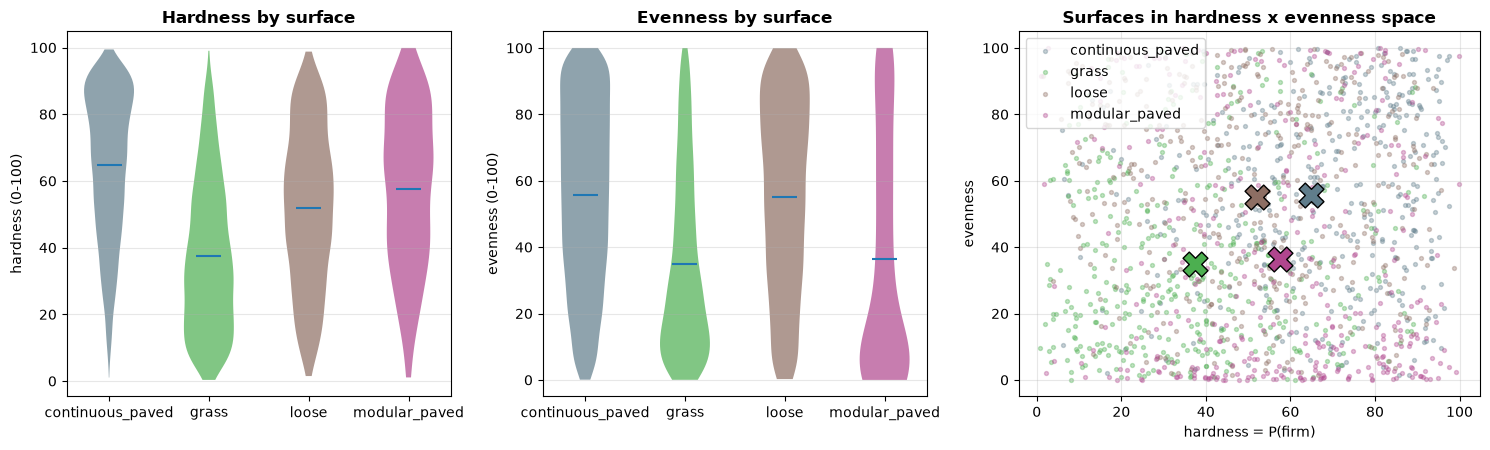

In [17]:
# ===== (D) hardness + evenness scales and surface populations =====
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.pipeline import Pipeline as _PL

SOFT = {'grass', 'soft'}
COMPL = [c for c in ['accel_jerk_ratio','accel_hf_frac','accel_spec_centroid','accel_zcr','gyro_hf_frac',
                     'gu_stance_frac','stance_duration','loading_rate_norm'] if c in full_df.columns]
hard_y = (~full_df['surface'].isin(SOFT)).astype(int).values; grp = full_df['source_recording'].values
oofh = np.zeros(len(full_df)); Xc2 = full_df[COMPL].fillna(0).values
if len(np.unique(hard_y)) == 2:
    for tr, te in _SGK(5, shuffle=True, random_state=42).split(Xc2, hard_y, grp):
        pl = _PL([('s', _SS()), ('lr', _LR(max_iter=1000, class_weight='balanced'))])
        pl.fit(Xc2[tr], hard_y[tr]); oofh[te] = pl.predict_proba(Xc2[te])[:, 1]
    full_df['hardness'] = oofh * 100
else:
    full_df['hardness'] = 50.0
EVEN_NEG = [c for c in ['orient_range_a','orient_range_b','gu_cop_wander','gu_press_jitter',
                        'orient_rest_a_roll3_std','orient_rest_b_roll3_std','gyro_x_std'] if c in full_df.columns]
ze = ((full_df[EVEN_NEG] - full_df[EVEN_NEG].mean()) / full_df[EVEN_NEG].std()).clip(-4, 4)
full_df['evenness'] = (-ze).mean(1).rank(pct=True) * 100
print('Mean scale position by surface:')
print(full_df.groupby('surface')[['hardness', 'evenness']].mean().round(1).to_string())
full_df[['surface','source_user','hardness','evenness']].to_csv(os.path.join(CHARTS_DIR, 'scales_scored.csv'), index=False)

_cl = sorted(full_df['surface'].unique())
fig = plt.figure(figsize=(15, 4.6)); gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])
for k, sca in enumerate(['hardness', 'evenness']):
    ax = fig.add_subplot(gs[0, k]); data = [full_df[full_df.surface == s][sca].values for s in _cl]
    parts = ax.violinplot(data, showmeans=True, showextrema=False)
    for pc, s in zip(parts['bodies'], _cl): pc.set_facecolor(SURFACE_COLORS.get(s, '#9E9E9E')); pc.set_alpha(.7)
    ax.set_xticks(range(1, len(_cl)+1)); ax.set_xticklabels(_cl); ax.set_ylabel(f'{sca} (0-100)')
    ax.set_title(f'{sca.capitalize()} by surface', fontweight='bold'); ax.grid(axis='y', alpha=.3)
ax = fig.add_subplot(gs[0, 2])
for s in _cl:
    d = full_df[full_df.surface == s].sample(min(400, int((full_df.surface == s).sum())), random_state=1)
    ax.scatter(d.hardness, d.evenness, s=8, alpha=.35, color=SURFACE_COLORS.get(s, '#9E9E9E'), label=s)
    ax.scatter(full_df[full_df.surface == s].hardness.mean(), full_df[full_df.surface == s].evenness.mean(),
               s=320, color=SURFACE_COLORS.get(s, '#9E9E9E'), edgecolor='k', marker='X', zorder=5)
ax.set_xlabel('hardness = P(firm)'); ax.set_ylabel('evenness'); ax.legend()
ax.set_title('Surfaces in hardness x evenness space', fontweight='bold'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'scales_populations.png'), dpi=140, bbox_inches='tight'); plt.show()

## 12. Per-surface feature summary statistics

For every feature the model uses (`FEATURE_COLS`), the count / mean / std / min / median / max **within each surface class**, plus an overall row. Also writes a tidy CSV (`feature_summary_by_surface.csv`) and a wide mean±std table you can drop into the write-up. The ANOVA F column (higher = better class separation) lets you sort features by how strongly they differ across surfaces.

In [18]:
# ===== per-surface summary statistics for every model feature =====
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler as _SS

_df = train_df.copy()
_feats = list(FEATURE_COLS)
_surfaces = list(classes)

# (1) tidy long-form: one row per (feature, surface) with the usual stats
_stat_names = ['count','mean','std','min','25%','50%','75%','max']
_rows = []
for f in _feats:
    for s in _surfaces:
        d = _df.loc[_df['surface'] == s, f].replace([np.inf,-np.inf], np.nan).dropna()
        desc = d.describe()
        row = {'feature': f, 'surface': s}
        row.update({k: (float(desc[k]) if k in desc else np.nan) for k in _stat_names})
        _rows.append(row)
    # overall (all surfaces) row
    d = _df[f].replace([np.inf,-np.inf], np.nan).dropna(); desc = d.describe()
    row = {'feature': f, 'surface': 'ALL'}
    row.update({k: (float(desc[k]) if k in desc else np.nan) for k in _stat_names})
    _rows.append(row)
summary_long = pd.DataFrame(_rows)

# (2) ANOVA F per feature (class separation), attach to the long table
_F, _p = f_classif(_SS().fit_transform(_df[_feats].fillna(0).values), _df['surface'].values)
_fser = pd.Series(_F, index=_feats)
summary_long['anova_F'] = summary_long['feature'].map(_fser).round(2)
summary_long = summary_long.sort_values(['anova_F','feature','surface'], ascending=[False,True,True])

# (3) compact wide view: mean (std) per surface, one row per feature, F-sorted
def _fmt(m, s): return f"{m:.3g} ({s:.2g})" if pd.notna(m) else ""
_wide = {}
for f in _feats:
    rec = {'anova_F': round(float(_fser[f]), 1)}
    for s in _surfaces:
        d = _df.loc[_df['surface'] == s, f].replace([np.inf,-np.inf], np.nan).dropna()
        rec[f'{s}: mean(std)'] = _fmt(d.mean(), d.std())
    _wide[f] = rec
summary_wide = pd.DataFrame(_wide).T
summary_wide = summary_wide.reindex(_fser.sort_values(ascending=False).index)   # F-sorted
summary_wide.index.name = 'feature'

# (4) save + show
_long_path = os.path.join(CHARTS_DIR, 'feature_summary_by_surface.csv')
_wide_path = os.path.join(CHARTS_DIR, 'feature_summary_mean_std_wide.csv')
summary_long.to_csv(_long_path, index=False)
summary_wide.to_csv(_wide_path)
print(f'wrote {_long_path}')
print(f'wrote {_wide_path}')
print(f'\n{len(_feats)} features x {len(_surfaces)} surfaces  (F-sorted; mean (std) per surface):')
try:
    from IPython.display import display
    display(summary_wide)
except Exception:
    print(summary_wide.to_string())

wrote ..\model_outputs\4class\Charts_Graphs\feature_summary_by_surface.csv
wrote ..\model_outputs\4class\Charts_Graphs\feature_summary_mean_std_wide.csv

43 features x 4 surfaces  (F-sorted; mean (std) per surface):


,anova_F,continuous_paved: mean(std),grass: mean(std),loose: mean(std),modular_paved: mean(std)
feature,,,,,
orient_rest_a_roll3_std,1765.0,0.789 (0.65),1.85 (1.1),1.03 (0.72),2.9 (2.2)
accel_jerk_ratio,846.1,0.453 (0.034),0.489 (0.04),0.461 (0.036),0.452 (0.047)
orient_rest_b_roll3_std,795.8,0.911 (0.83),1.76 (1.2),1.14 (0.93),2.35 (2.1)
gyro_x_std,611.5,4.32e+06 (2.6e+05),4.1e+06 (2.7e+05),4.19e+06 (2.4e+05),4.16e+06 (2.1e+05)
stance_duration,362.0,1.02 (0.091),1.08 (0.11),1.05 (0.1),0.992 (0.032)
gyro_z_std,271.9,1.25e+06 (3.5e+05),1.12e+06 (2.5e+05),1.16e+06 (2.6e+05),9.18e+05 (1.6e+05)
accel_spec_centroid,271.6,4.43 (0.55),4.14 (0.46),4.25 (0.49),4.43 (0.44)
gyro_x_strike,258.8,8.72e+06 (6.1e+05),8.37e+06 (6.9e+05),8.56e+06 (5.8e+05),8.68e+06 (7.4e+05)
accel_zcr,249.5,0.0698 (0.018),0.0792 (0.019),0.0759 (0.019),0.0801 (0.022)


## 13. Box-and-whisker plots by surface

A boxplot per feature, split by surface class (box = IQR, line = median, whiskers = 1.5×IQR, points beyond = outliers). Features are ordered by ANOVA F (most class-separating first), and each value is z-scored **within the feature** so all panels share a comparable y-scale — you're reading whether the coloured boxes sit apart (separates the classes) or overlap (doesn't). Saves `feature_boxplots.png`.

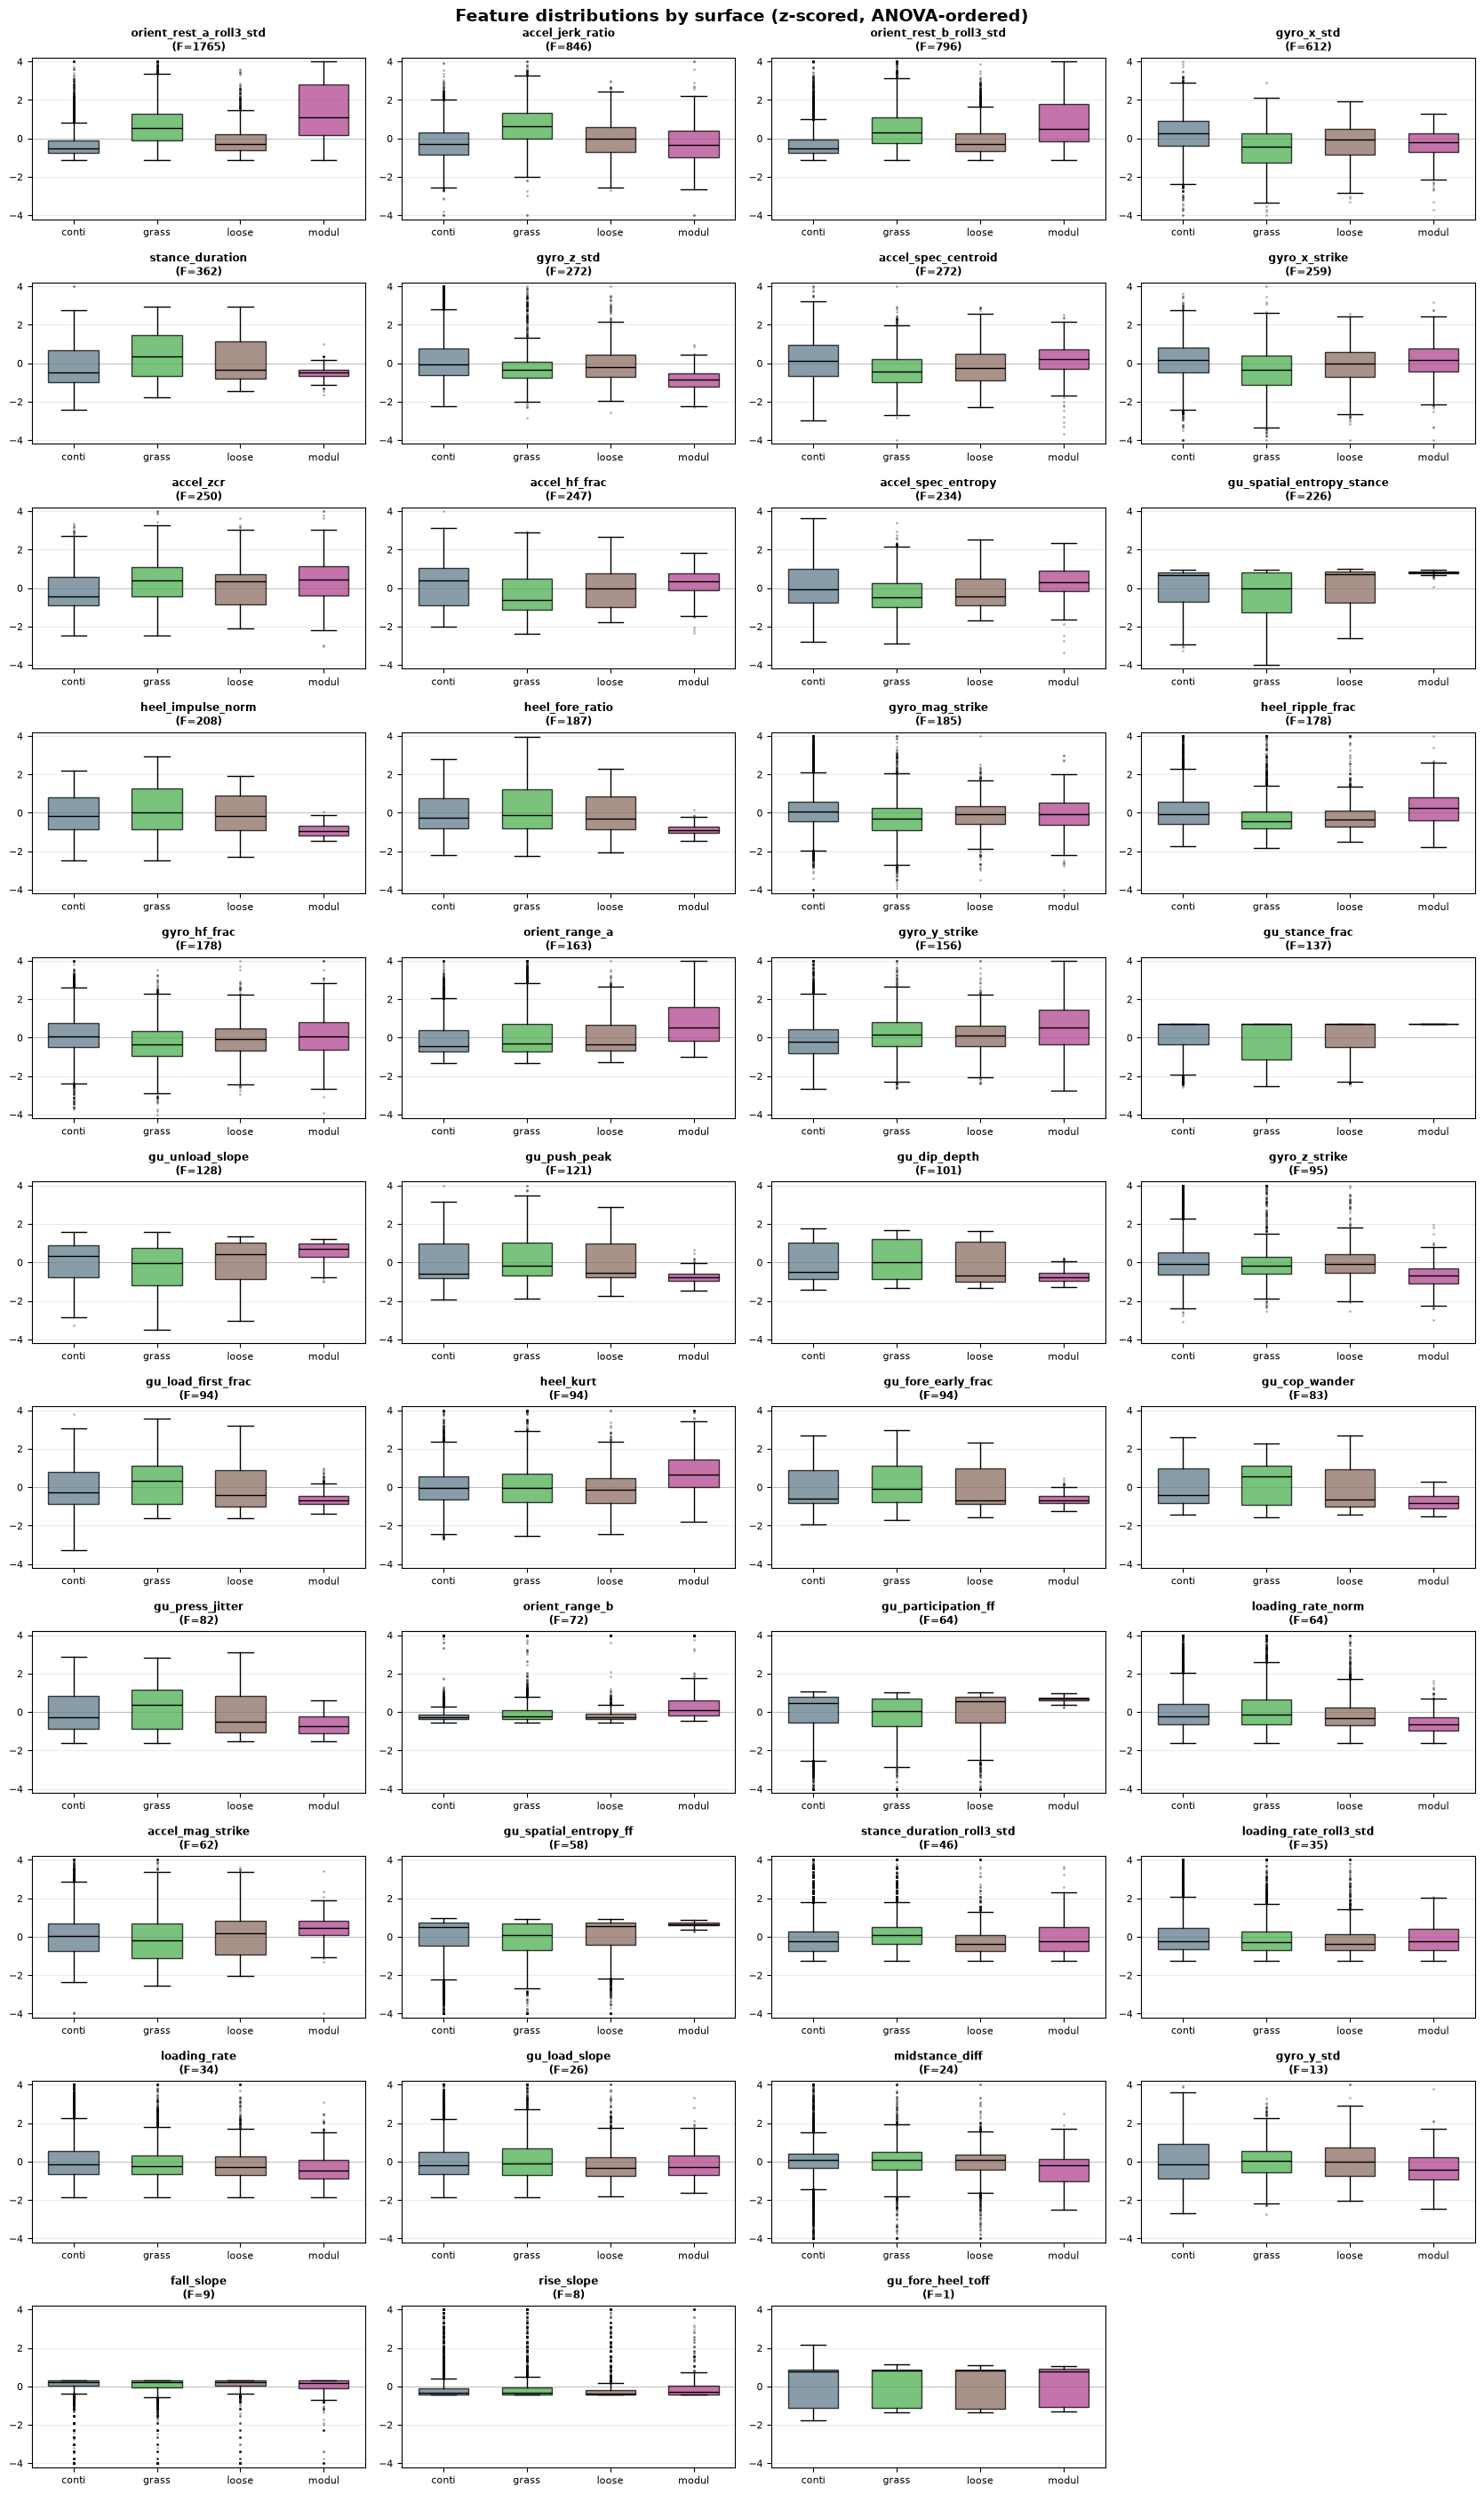

wrote ..\model_outputs\4class\Charts_Graphs\feature_boxplots.png


In [19]:
# ===== box-and-whisker plots of every model feature, by surface =====
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler as _SS

_feats = list(FEATURE_COLS); _surfaces = list(classes)
_X = _df_num = train_df[_feats].replace([np.inf,-np.inf], np.nan)

# order features by class-separation (ANOVA F)
_F, _p = f_classif(_SS().fit_transform(train_df[_feats].fillna(0).values), train_df['surface'].values)
_order = pd.Series(_F, index=_feats).sort_values(ascending=False).index.tolist()

# z-score each feature so panels are visually comparable (robust to the feature's own scale)
_z = (_X - _X.mean()) / _X.std(ddof=0)
_z['surface'] = train_df['surface'].values

_ncol = 4
_nrow = int(np.ceil(len(_order) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(_ncol*4.2, _nrow*2.6))
axes = np.atleast_1d(axes).ravel()
for ax, feat in zip(axes, _order):
    data = [ _z.loc[_z['surface']==s, feat].replace([np.inf,-np.inf], np.nan).dropna().clip(-4,4).values
             for s in _surfaces ]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_xticks(range(1, len(_surfaces)+1)); ax.set_xticklabels([str(s)[:5] for s in _surfaces])
    for patch, s in zip(bp['boxes'], _surfaces):
        patch.set_facecolor(SURFACE_COLORS.get(s, '#9E9E9E')); patch.set_alpha(0.75)
    for med in bp['medians']: med.set_color('black')
    ax.set_title(f"{feat}\n(F={pd.Series(_F, index=_feats)[feat]:.0f})", fontsize=8.5, fontweight='bold')
    ax.tick_params(labelsize=8); ax.axhline(0, color='#bbb', lw=0.6, zorder=0); ax.grid(axis='y', alpha=0.25)
    ax.set_ylim(-4.2, 4.2)
for ax in axes[len(_order):]:
    ax.set_visible(False)
fig.suptitle('Feature distributions by surface (z-scored, ANOVA-ordered)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.99])
plt.savefig(os.path.join(CHARTS_DIR, 'feature_boxplots.png'), bbox_inches='tight', dpi=140)
plt.show()
print('wrote', os.path.join(CHARTS_DIR, 'feature_boxplots.png'))